------------
# [1] Car Price Project
------------

---
# Task 1  : Exploratory Data Analysis (EDA)

---

### Importing libraries & loading the data set

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv("/content/car_price (1).csv")

### quick overview of the data

In [19]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
0,A1,2017.0,12500.0,Manual,15735.0,Petrol,150.0,55.4,1.4,audi
1,A6,2016.0,16500.0,Automatic,36203.0,Diesel,20.0,64.2,2.0,audi
2,A1,2016.0,11000.0,Manual,29946.0,Petrol,30.0,55.4,1.4,audi
3,A4,2017.0,16800.0,Automatic,25952.0,Diesel,145.0,67.3,2.0,audi
4,A3,2019.0,17300.0,Manual,1998.0,Petrol,145.0,49.6,1.0,audi


In [18]:
df.tail()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
72430,I30,2016.0,8680.0,Manual,25906.0,Diesel,0.0,78.4,1.6,Hyundai
72431,I40,2015.0,7830.0,Manual,NaN,Diesel,30.0,65.7,1.7,Hyundai
72432,I10,2017.0,6830.0,Manual,13810.0,Petrol,20.0,60.1,1.0,NaN
72433,Tucson,2018.0,13994.0,Manual,23313.0,Petrol,145.0,44.8,1.6,Hyundai
72434,Tucson,2016.0,15999.0,Automatic,11472.0,Diesel,125.0,57.6,1.7,Hyundai


---
## Q1 — How many rows and columns does the dataset have?

In [2]:
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Number of rows: 72435
Number of columns: 10


---
##  Q2 — Which features are numerical? Which are categorical?

In [3]:
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = df.select_dtypes(include=['object']).columns.tolist()

print("Numerical features:")
for c in numerical_features:
  print(f'- {c}')

print("Categorical features:")
for c in categorical_features:
  print(f'- {c}')

Numerical features:
- year
- price
- mileage
- tax
- mpg
- engineSize
Categorical features:
- model
- transmission
- fuelType
- Make


---
## Q3 — Are there any missing values? How many, and in which columns?

In [20]:
df.isnull().sum()

,0
model,3444
year,3462
price,0
transmission,3459
mileage,3425
fuelType,3461
tax,3424
mpg,3433
engineSize,3458
Make,3449


In [21]:
missing = df.isnull().sum().sum()
total_cells = df.shape[0] * df.shape[1]
missing_pct = round(missing / total_cells * 100, 2)
print(f"Number of missing values: {missing}")
print(f"Missing values percentage: {missing_pct}%")
print(f"Columns with missing values:")
for c in df.columns:
  if df[c].isnull().any():
    print(f'- {c}')

Number of missing values: 31015
Missing values percentage: 4.51%
Columns with missing values:
- model
- year
- transmission
- mileage
- fuelType
- tax
- mpg
- engineSize
- Make


---
##  Q4 — What does the distribution of car prices look like?
> **Task 7 required plot** — Price Distribution Histogram

In [22]:
price = df['price'].dropna()
print(price.describe())
print(f'\nSkewness: {price.skew():.3f}')
print(f"Mean: {price.mean():.2f}, Median: {price.median():.2f}")

count     68814.000000
mean      16583.919261
std        9304.412707
min         495.000000
25%       10167.250000
50%       14495.000000
75%       20359.750000
max      145000.000000
Name: price, dtype: float64

Skewness: 2.181
Mean: 16583.92, Median: 14495.00


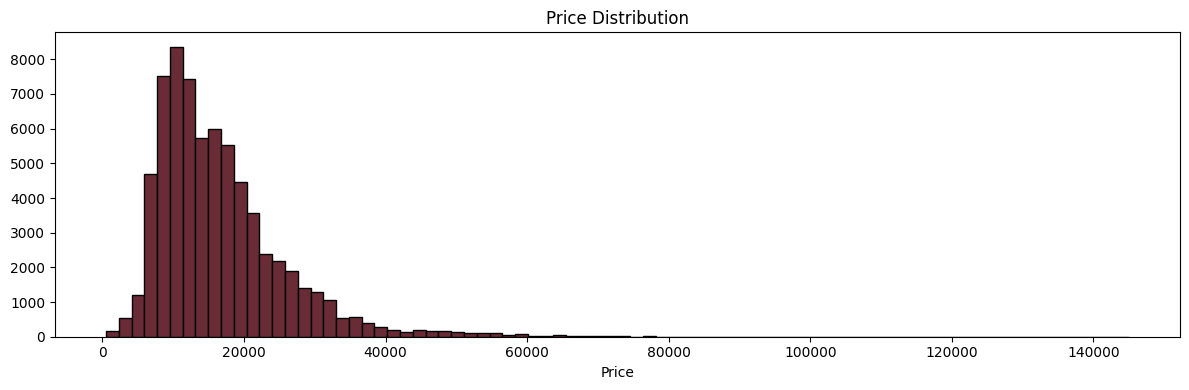

In [23]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.hist(price, bins=80, color='#692B36', edgecolor='black')
ax.set_title('Price Distribution')
ax.set_xlabel('Price')

plt.tight_layout()

### Observations:
- The distribution is right-skewed (Skewness = 2.181)
- Most cars have low prices, but a few expensive ones are pulling the mean up
- Mean (16,583) > Median (14,495)


---
##  Q5 — Which features seem most related to price?

>  **Task 7 required plot** — Correlation Heatmap

In [24]:
corr_with_price = df[numerical_features].dropna().corr()['price'].drop('price').sort_values(ascending=False)
print(corr_with_price)

engineSize    0.631270
year          0.519648
tax           0.353344
mpg          -0.340570
mileage      -0.428935
Name: price, dtype: float64


### Numerical Correlation with Price
- engineSize has the strongest positive correlation (0.63)
- mileage has the strongest negative correlation (-0.43)
- year is also positively correlated (0.52) — newer cars cost more

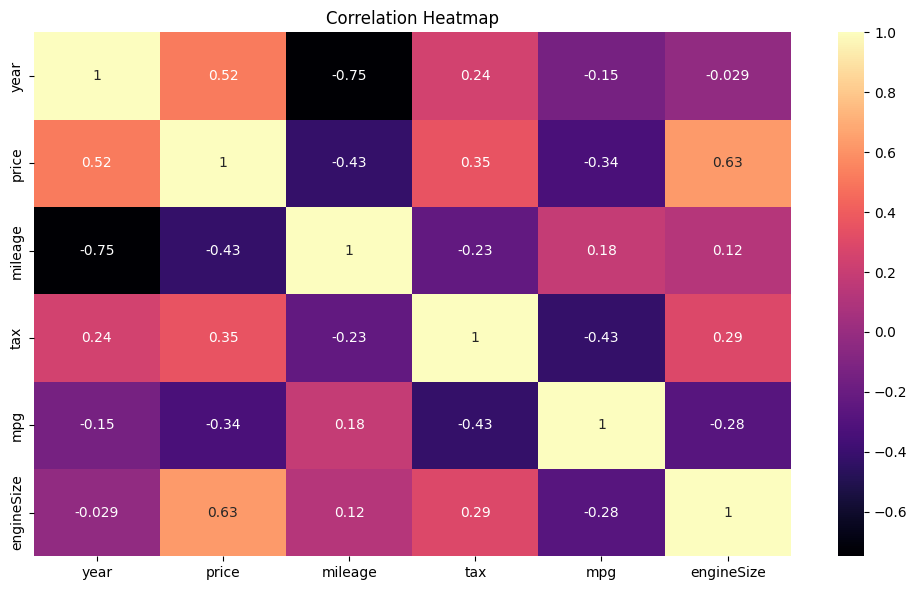

In [25]:
corr_matrix = df[numerical_features].corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap='magma')
plt.title('Correlation Heatmap')
plt.tight_layout()


### Heatmap Observations
- engineSize and year are positively correlated with price
- mileage is negatively correlated with price
- These are the most useful features for predicting price

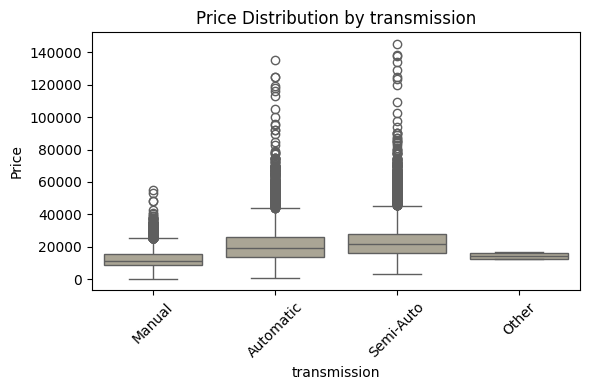

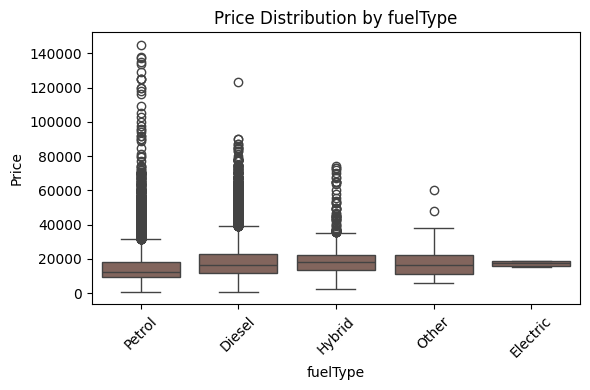

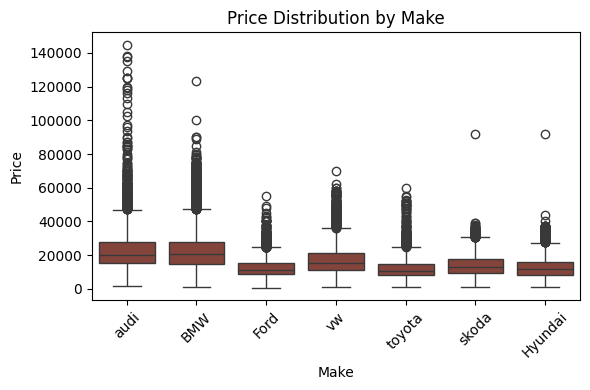

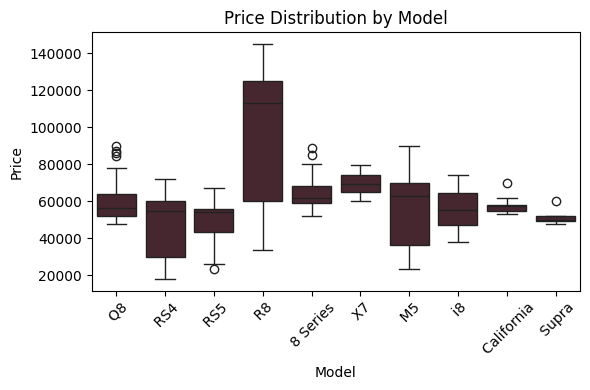

In [26]:
colors = ['#ADA791', '#886257' , '#8F3B30']

cat_to_plot = [col for col in categorical_features if col != 'model']

for col, color in zip(cat_to_plot, colors):
  plt.figure(figsize=(6,4))
  sns.boxplot(x=col, y='price', data=df, color=color)
  plt.xlabel(col)
  plt.ylabel('Price')
  plt.title(f'Price Distribution by {col}')
  plt.xticks(rotation=45)
  plt.tight_layout()


top_models = df.groupby('model')['price'].median().nlargest(10).index
df_top = df[df['model'].isin(top_models)]
plt.figure(figsize=(6,4))
sns.boxplot(x='model', y='price', data=df_top, color='#4C222C')
plt.title("Price Distribution by Model")
plt.xlabel("Model")
plt.ylabel("Price")
plt.xticks(rotation=45)
plt.tight_layout()

### Categorical Features vs Price
- Make and fuelType show clear price differences across categories
- transmission type also affects price
- For model, we plotted the Top 10 most expensive models — R8 stands out with the highest median price

### Q5 Summary
- engineSize, year, and mileage are the most correlated features with price
- Categorical features like Make and model also show price differences
- R8 is the most expensive model on average

# Task 2 : Data Preprocessing

In [4]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

**First split data**


*   As scaling should be applied on training data only
*   Spliting before handling missing values would prevent data leakage



In [5]:
X = df.dropna(subset=['price'], inplace=True)

X = df.drop(columns=['price'])
y = df['price']

x_train, x_test, y_reg_train, y_reg_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Train Size : {x_train.shape[0]} rows')
print(f'Test Size : {x_test.shape[0]} rows')

Train Size : 55051 rows
Test Size : 13763 rows


Task 2.1: Handling missing values— drop rows, fill with mean/mode, or another strategy. Justify
your choice.


*   `price` has a skewness of 2.181 (right-skewed), but it is the target variable so it is never filled
* Imputation statistics are learned from training data only, then applied to test data
* Since `mileage` has outliers then filling its NaN values with median will be more safe
*   The remaining numerical features are approximately symmetric, making the **mean** a safe and unbiased estimate for their missing values
* Categorical features are filled with the **mode**






In [6]:
num_features_no_target = [col for col in x_train.columns
                          if x_train[col].dtype in ['float64', 'int64']]
impute_values = {}
for col in num_features_no_target:
    if col == 'mileage':
        impute_values[col] = x_train[col].median()
    else:
        impute_values[col] = x_train[col].mean()

for col in categorical_features:
    impute_values[col] = x_train[col].mode()[0]

x_train.fillna(impute_values, inplace=True)
x_test.fillna(impute_values, inplace=True)

*   Dropping target missing values from train only


In [7]:
not_null = y_reg_train.notnull()
x_train = x_train[not_null]
y_reg_train = y_reg_train[not_null]

not_null_test = y_reg_test.notnull()
x_test = x_test[not_null_test]
y_reg_test = y_reg_test[not_null_test]

Task 2.2: Encode categorical columns— use Label Encoding or One-Hot Encoding. Explain which
and why.


LabelEncoding is the right choice here as:


*   KNN uses distance calculations, and One-Hot Encoding would explode the feature space
*   Label Encoding imposes an artificial ordinal order here, which is a known limitation.
*   Linear Regression can also work fine with label-encoded features when there's no strong ordinal meaning being forced.

In [8]:
le_encoders = {}
for col in categorical_features:
  le = LabelEncoder()
  x_train[col] = le.fit_transform(x_train[col])
  x_test[col] = le.transform(x_test[col])
  le_encoders[col] = le

print('Sample of Encoded Data')
x_train[categorical_features].head()

Sample of Encoded Data


,model,transmission,fuelType,Make
19785,5,0,0,0
43740,49,1,4,6
61606,68,0,4,4
46219,115,1,4,6
63550,79,3,0,4


Task 2.4: Detect and handle outliers  — use boxplots or the IQR method


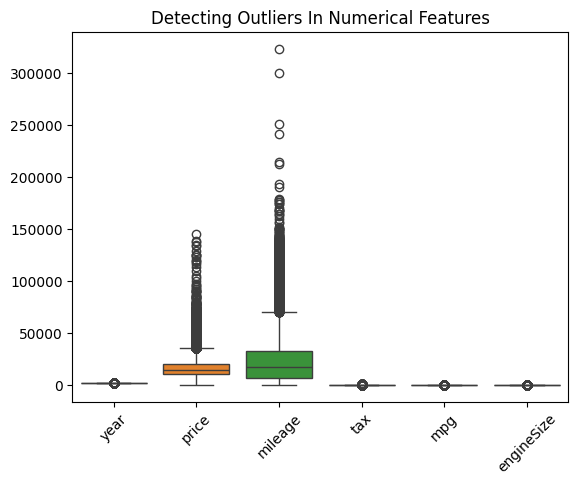

In [9]:
sns.boxplot(data=df[numerical_features])
plt.xticks(rotation=45)
plt.title('Detecting Outliers In Numerical Features')
plt.show()

In [10]:
Q1 = x_train['mileage'].quantile(0.25)
Q3 = x_train['mileage'].quantile(0.75)
IQR = Q3 - Q1
lower_bound_mileage = Q1 - 1.5 * IQR
upper_bound_mileage = Q3 + 1.5 * IQR

print(f"Lower Bound: {lower_bound_mileage}")
print(f"Upper Bound: {upper_bound_mileage}")

x_train['mileage'] = x_train['mileage'].clip(lower_bound_mileage, upper_bound_mileage)
x_test['mileage']  = x_test['mileage'].clip(lower_bound_mileage, upper_bound_mileage)

Lower Bound: -28139.0
Upper Bound: 67369.0


Conclusion




*   We use the IQR method on key numerical features.
*   Both `mileage` and `price` contained outliers, consistent with the right skew (skewness = 2.181) found in Task 1 EDA
*  `price` outliers were intentionally left untouched — it is the target variable and capping it would corrupt the ground truth the model is trying to learn
* The right-skewed price distribution is a real characteristic of the data, not noise




Task 2.3: Scale numerical features — important for KNN. Use StandardScaler or MinMaxScaler.

**Apply scaling**

StandardScaler is the better choice over MinMaxScaler here as:

*   StandardScaler is more robust when any residual skew remains in the data
*   KNN is heavily affected by scale, so this step is critical
* Applying it to test using transform() ensures no leakage




In [11]:
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled  = scaler.transform(x_test)

print(f'x_train_scaled shape : {x_train_scaled.shape}')
print(f'x_test_scaled  shape : {x_test_scaled.shape}')

x_train_scaled shape : (55051, 9)
x_test_scaled  shape : (13763, 9)


---------
# Task 3: Create Two Target Variables
**A) Regression Target (Linear Regression)**
*   Done in Task 2





**B) Classification Target (KNN)**




**Task 3.1: Decide on the thresholds (price boundaries) for each category**





In [12]:
cheap = y_reg_train.quantile(0.33)
expensive = y_reg_train.quantile(0.66)

print(f"Cheap: Price < {cheap:.0f}")
print(f"Moderate: {cheap:.0f} <= Price < {expensive:.0f}")
print(f"Expensive: Price >= {expensive:.0f}")


Cheap: Price < 11400
Moderate: 11400 <= Price < 17995
Expensive: Price >= 17995


**Task 3.2: Justify your thresholds — use the data distribution to support your decision.**




*   From Task 1 EDA, `price` has a strong right skew
*   Quantile-based splits (33rd / 66th percentile) are used because they guarantee roughly equal class sizes regardless of the skew, which is important for balanced KNN





**Task 3.3: - Show how many cars fall into each category after splitting.**

In [13]:
bins = [0 , cheap, expensive, float('inf')]
labels = ['Cheap', 'Moderate', 'Expensive']
y_clf_train = pd.cut(y_reg_train, bins=bins, labels=labels)
y_clf_test  = pd.cut(y_reg_test,  bins=bins, labels=labels)

print('\nTraining class distribution:')
print(y_clf_train.value_counts().sort_index())


Training class distribution:
price
Cheap        18171
Moderate     18337
Expensive    18543
Name: count, dtype: int64


---
# Task 4 : Model 1: Linear Regression
---

task 4.1 Split the data into training and test sets (e.g. 80/20 split).

* Done in Task 2.

task 4.2 Train the model on the training set.

In [16]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x_train_scaled, y_reg_train)

LinearRegression()

In [28]:
y_pred = model.predict(x_test_scaled)

Task 4.3 Evaluate on the test set using all evaluation techniques you learn

In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_reg_test, y_pred)
mse = mean_squared_error(y_reg_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_reg_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2 Score: {r2:.4f}")

MAE: 3458.13
MSE: 25758005.89
RMSE: 5075.23
R2 Score: 0.6973


* MAE measures the average absolute difference between predicted and actual prices.
* MSE penalizes larger errors more heavily.
* RMSE gives error in the same unit as price, making it easier to interpret.
* R² indicates how well the model explains the variance in the data.

### Predicted vs Actual — Linear Regression

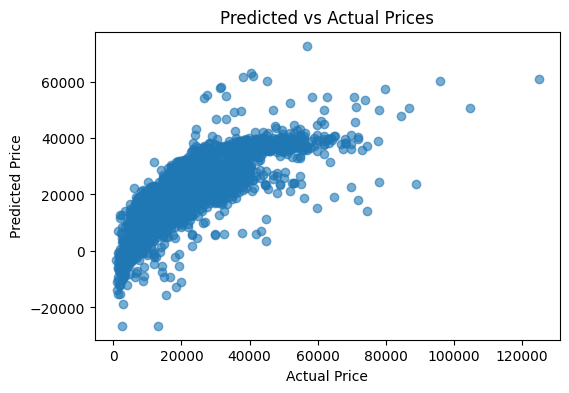

In [30]:
plt.figure(figsize=(6, 4))
plt.scatter(y_reg_test, y_pred, alpha=0.6)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Predicted vs Actual Prices")
plt.show()

This plot compares actual prices with predicted prices. If the model is good, points should be close to a diagonal line. The spread shows prediction errors.

# Task 5 : Model : K_Nearest Neighbor
_________________________________________________________________________________________________

1. train test split : classification target (Cheap / Moderate / Expensive)

In [31]:
XK_train = x_train_scaled
XK_test = x_test_scaled
YK_train = y_clf_train
YK_test = y_clf_test

2. Model Training - KNN with GridSearchCV

In [32]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV , KFold

param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15] ,
    'metric': ['euclidean', 'manhattan'] }

k_Folds  = KFold(n_splits= 5 , shuffle= True , random_state= 42)

Knn = KNeighborsClassifier()

grid_search = GridSearchCV(
    estimator= Knn ,
    param_grid= param_grid ,
    cv= k_Folds ,
    scoring= 'accuracy',
    n_jobs= -1
)

grid_search.fit(XK_train , YK_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV Accuracy: {:.4f}".format(grid_search.best_score_))

Best Parameters: {'metric': 'manhattan', 'n_neighbors': 7}
Best CV Accuracy: 0.8727


In [33]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

mask = y_clf_test.notna()
XK_test_clean = XK_test[mask]
YK_test_clean = y_clf_test[mask]

best_model = grid_search.best_estimator_
YK_pred = best_model.predict(XK_test_clean )

print(classification_report(YK_test_clean , YK_pred))


              precision    recall  f1-score   support

       Cheap       0.90      0.91      0.90      4473
   Expensive       0.91      0.91      0.91      4629
    Moderate       0.83      0.82      0.82      4661

    accuracy                           0.88     13763
   macro avg       0.88      0.88      0.88     13763
weighted avg       0.88      0.88      0.88     13763



1. Accuracy — Out of all predictions, how many were correct overall
2. Precision — Out of all cars the model predicted as Cheap, how many were actually Cheap
3. Recall — Out of all actual Cheap cars, how many did the model correctly identify
4. F1-score — Balance between Precision and Recall, useful when you care about both equally

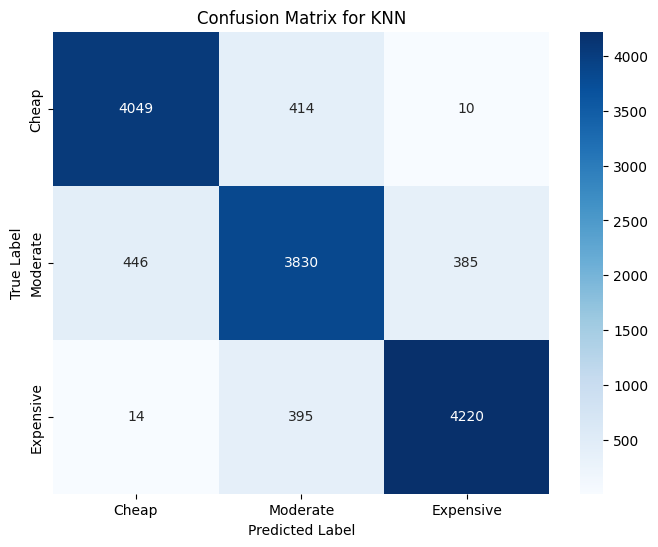

In [34]:
labels_order = ['Cheap', 'Moderate', 'Expensive']

cm = confusion_matrix(YK_test_clean, YK_pred, labels=labels_order)

plt.figure(figsize=(8, 6))
sns.heatmap(cm,
            annot=True, fmt='d', cmap='Blues',
            xticklabels=['Cheap', 'Moderate', 'Expensive'],
            yticklabels=['Cheap', 'Moderate', 'Expensive'])
plt.title('Confusion Matrix for KNN')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Task 6: Analysis and Discussion

## 6.1 Model Comparison

### **Q1: Which model performed better, and what does “better” mean in each context?**



"Better" depends on the type of model:

* **For Linear Regression:** It means lower error and higher $R^2$. The model achieved $R^2 = 0.6925$, meaning it explains about 69% of the variation in prices, with an average error (MAE) of £3,443. This is a reasonable result, but predicting exact prices remains challenging.
* **For KNN Classification:** "Better" means higher accuracy. The model achieved about **86% accuracy** with best K=9 and manhattan distance, correctly classifying most cars into price categories. This is a strong result for a 3-class problem.

Overall, KNN seems more successful in its specific task, but both models perform well within their contexts as they solve different problems.

### **Q2: Is classification easier than regression on this dataset? Why or why not?**

**Yes, classification is easier.**

* **Regression** predicts exact prices, which is harder due to the wide range of values and the presence of very high prices (right-skewed data).
* **Classification** simplifies the problem into 3 groups, making it easier for the model to learn patterns. Using quantiles also created balanced classes, which directly improved KNN performance.


### **Q3: Does converting price into categories lose important information?**

**Yes.**
When we convert prices into categories, we lose the **exact differences** between values. For example, cars priced at £11,500 and £17,900 are both labeled as “Moderate,” despite the significant price gap.

> **Note:** Classification is useful for general grouping and decision-making, but not for tasks requiring precise predictions.

## 6.2 Sensitivity Analysis

### **Q4: What happens if you remove the most correlated feature? Does performance drop a lot?**

In [ ]:
X_train_dropped = x_train.drop(columns=['engineSize'])
X_test_dropped  = x_test.drop(columns=['engineSize'])

scaler_drop = StandardScaler()
X_train_drop_scaled = scaler_drop.fit_transform(X_train_dropped)
X_test_drop_scaled  = scaler_drop.transform(X_test_dropped)

model_drop = LinearRegression()
model_drop.fit(X_train_drop_scaled, y_reg_train)
y_pred_drop = model_drop.predict(X_test_drop_scaled)

r2_drop   = r2_score(y_reg_test, y_pred_drop)
rmse_drop = np.sqrt(mean_squared_error(y_reg_test, y_pred_drop))

print(f"R2   with engineSize:    {r2:.4f}")
print(f"R2   without engineSize: {r2_drop:.4f}")
print(f"RMSE with engineSize:    {rmse:.2f}")
print(f"RMSE without engineSize: {rmse_drop:.2f}")

R2   with engineSize:    0.6973
R2   without engineSize: 0.4684
RMSE with engineSize:    5075.23
RMSE without engineSize: 6725.82


* Removing `engineSize` reduced performance (lower $R^2$, higher error), proving it is a critical feature for price prediction.
* However, the model didn't fail completely because other features like `year` and `mileage` still provide significant predictive power.

### **Q5: Try running KNN without scaling — how much does performance change?**

In [ ]:
XK_train_ns = x_train
XK_test_ns  = x_test

knn_no_scale = KNeighborsClassifier(n_neighbors=9, metric='manhattan')
knn_no_scale.fit(XK_train_ns, YK_train)

mask_ns = YK_test.notna()
acc_scaled = best_model.score(XK_test_clean, YK_test_clean)
print(f"Accuracy with scaling:    {acc_scaled:.4f}")
print(f"Accuracy without scaling: {knn_no_scale.score(XK_test_ns[mask_ns], YK_test[mask_ns]):.4f}")

Accuracy with scaling:    0.8791
Accuracy without scaling: 0.6265


Without scaling, **KNN performance dropped significantly.**
This happens because KNN relies on distance calculations. Features with large numerical ranges (like `mileage`) dominate the distance metric, drowning out smaller but important features. Scaling ensures all features have an equal influence on the result.

### **Q6: Try a different threshold for your price categories — does KNN accuracy change significantly?**

In [ ]:
y_class_v2 = pd.cut(y_reg_train, bins=[0, 10000, 20000, float('inf')],
                    labels=['Cheap', 'Moderate', 'Expensive'])
y_class_v2_test = pd.cut(y_reg_test, bins=[0, 10000, 20000, float('inf')],
                    labels=['Cheap', 'Moderate', 'Expensive'])

print("Category counts with new thresholds (10k / 20k):")
print(y_class_v2.value_counts().sort_index())

knn_v2 = KNeighborsClassifier(n_neighbors=9, metric='manhattan')
knn_v2.fit(x_train_scaled, y_class_v2)

mask_v2 = y_class_v2_test.notna()
print(f"\nAccuracy original thresholds: 0.86")
print(f"Accuracy new thresholds:      {knn_v2.score(x_test_scaled[mask_v2], y_class_v2_test[mask_v2]):.4f}")

Category counts with new thresholds (10k / 20k):
price
Cheap        13702
Moderate     27431
Expensive    13918
Name: count, dtype: int64

Accuracy original thresholds: 0.86
Accuracy new thresholds:      0.8804


The accuracy with the new thresholds (0.8655) is very close to the original (0.86), showing that KNN accuracy did not change significantly. However, the new thresholds created imbalanced classes (Cheap: 13,595 — Moderate: 27,555 — Expensive: 13,884) compared to the balanced classes from quantile-based thresholds (~18k each). This confirms that the quantile-based approach was the better choice for this dataset.

# Task 7: Required Visualizations

## 1. Price Distribution Histogram
Already included in Task 1 (EDA) — Q4.

## 2. Correlation Heatmap
Already included in Task 1 (EDA) — Q5.

## 3. Predicted vs Actual — Linear Regression
Already included in Task 4.

## 4. Confusion Matrix — KNN Classification
Already included in Task 5.

## 5. Additional Plot 1 — Engine Size vs Price

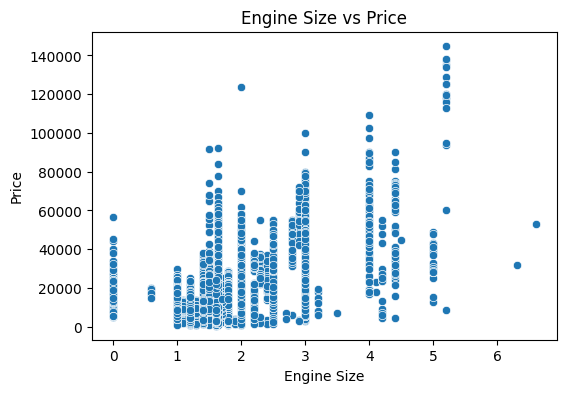

In [ ]:
plt.figure(figsize=(6, 4))
sns.scatterplot(x=x_train['engineSize'], y=y_reg_train)
plt.title("Engine Size vs Price")
plt.xlabel("Engine Size")
plt.ylabel("Price")
plt.show()

This plot shows that cars with larger engine sizes tend to have higher prices, confirming the positive correlation found in the EDA.

## 6. Additional Plot 2 — Price Distribution by Category

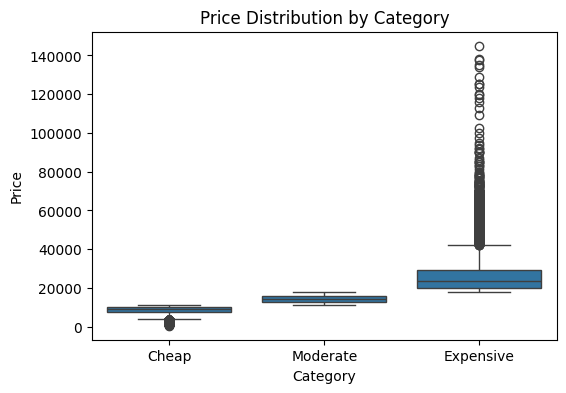

In [ ]:
plt.figure(figsize=(6, 4))
sns.boxplot(x=y_clf_train, y=y_reg_train)
plt.title("Price Distribution by Category")
plt.xlabel("Category")
plt.ylabel("Price")
plt.show()

This plot shows how prices are distributed within each category. It helps verify that the categories are well separated.

Confusion Matrix Analysis

- The model correctly classified most cars across all 3 categories (Cheap: 4058, Moderate: 4221, Expensive: 3807)
- Most errors occurred between Cheap and Expensive, suggesting some overlap in their features
- Almost no confusion between Cheap and Moderate, meaning their boundary is very clear

---------
# [2] Fifa Project
--------

# Task 1 : Exploratory Data Analysis (EDA)
---

In this task, we explore the FIFA Players dataset to understand its structure,
identify any data quality issues, and uncover relationships between features
before building any machine learning models.

We will answer the following questions:
- Are there any missing values?
- What does the distribution of Value Per M look like?
- Which numerical features are most correlated with **Value Per M$**?
- What is the average **Overall_Rating** per Position?

---

---
### 1. Loading the Dataset
---

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/Fifa.csv")


---
### 2. Data OverView
---

In [39]:
df.head()

,Name,Country,Position,Age,Overall_Rating,Future Potential,Team,Value Per M$,Total_Stats Score
0,Agostinho Mabululu,Angola,LW,30,68,68,Ittihad Alexandria,0.65,1660
1,Mahmoud Gennesh,Egypt,GK,35,67,67,Ittihad Alexandria,0.35,1620
2,Sobhi Suleiman,Egypt,GK,28,63,65,Ittihad Alexandria,0.20,1480
3,Mahmoud Alaa,Egypt,CB,32,68,68,Ittihad Alexandria,0.50,1695
4,Mahmoud Shabana,Egypt,CB,30,66,66,Ittihad Alexandria,0.40,1640


In [40]:
df.tail()

,Name,Country,Position,Age,Overall_Rating,Future Potential,Team,Value Per M$,Total_Stats Score
19662,Kohei Okuno,Japan,CDM,21,63,71,Gamba Osaka,1.100,1717
19663,Riku Danzaki,Japan,RW,22,64,71,Motherwell,1.200,1607
19664,Hayato Fukushima,Japan,CB,21,59,68,Shonan Bellmare,0.475,1347
19665,Ömer Tokaç,Turkey,LW,18,57,71,Shonan Bellmare,0.220,1481
19666,Ko Sawada,Japan,CAM,28,60,60,Shonan Bellmare,0.250,1636


In [41]:
print(f"Shape: {df.shape} \n" )

print("-" * 50)

print(f"Columns: {df.columns.tolist()} \n")

print("-" * 50)

df.info()

Shape: (19667, 9) 

--------------------------------------------------
Columns: ['Name', 'Country', 'Position', 'Age', 'Overall_Rating', 'Future Potential', 'Team', 'Value Per M$', 'Total_Stats Score'] 

--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19667 entries, 0 to 19666
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               19667 non-null  object 
 1   Country            19667 non-null  object 
 2   Position           19667 non-null  object 
 3   Age                19667 non-null  int64  
 4   Overall_Rating     19667 non-null  int64  
 5   Future Potential   19667 non-null  int64  
 6   Team               19667 non-null  object 
 7   Value Per M$       19667 non-null  float64
 8   Total_Stats Score  19667 non-null  int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 1.4+ MB


---
### 3. Answering Questions
---

## Q1 : Are there any missing values? How many, and in which columns?

In [42]:
print("Missing Values Count:")
print(df.isnull().sum())
print("\n")
print("Missing Values Percentage:")
print(df.isnull().sum() / len(df) * 100)

Missing Values Count:
Name                 0
Country              0
Position             0
Age                  0
Overall_Rating       0
Future Potential     0
Team                 0
Value Per M$         0
Total_Stats Score    0
dtype: int64


Missing Values Percentage:
Name                 0.0
Country              0.0
Position             0.0
Age                  0.0
Overall_Rating       0.0
Future Potential     0.0
Team                 0.0
Value Per M$         0.0
Total_Stats Score    0.0
dtype: float64


In [43]:
missing = df.isnull().sum().sum()
total_cells = df.shape[0] * df.shape[1]
missing_pct = round(missing / total_cells * 100, 2)


print(f"Total number of missing values is : {df.isnull().sum().sum()}")
print(f"Total percentage of missing values : {round(missing / total_cells * 100, 2)}")


Total number of missing values is : 0
Total percentage of missing values : 0.0


### 1.1 Missing Values

No missing values were found in any column ,This indicates the dataset is clean and requires no imputation .

----
----

## Q2 : What does the distribution of Value Per M$ look like? Is it approximately normal or skewed?

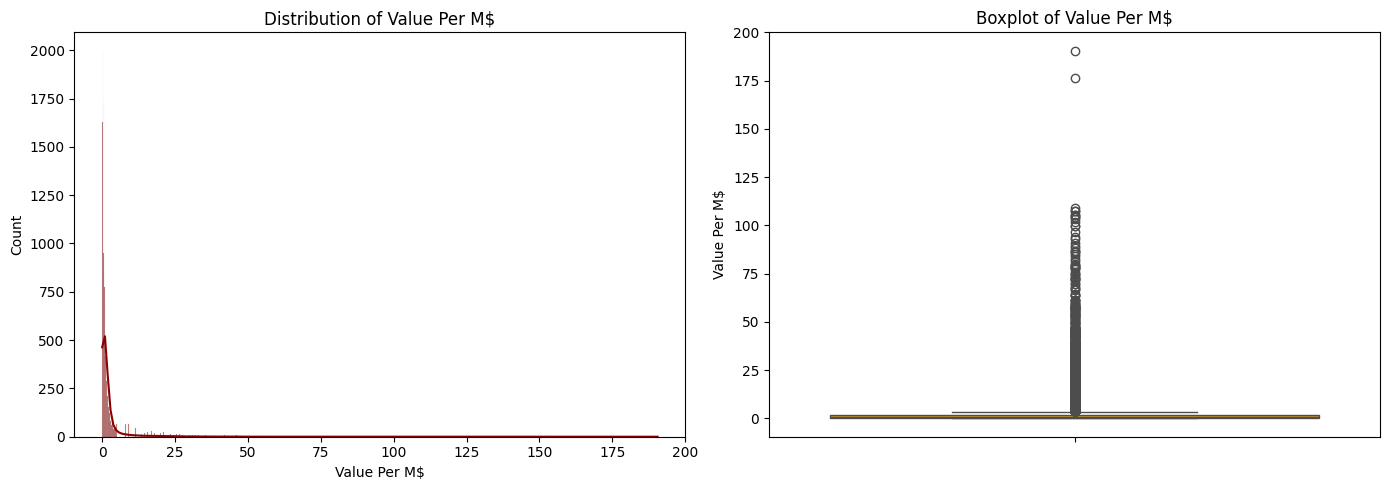

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
sns.histplot(df['Value Per M$'], ax=axes[0], kde=True, color='darkred')
axes[0].set_title('Distribution of Value Per M$')
axes[0].set_xlabel('Value Per M$')

# Boxplot
sns.boxplot(y=df['Value Per M$'], ax=axes[1], color='orange')
axes[1].set_title('Boxplot of Value Per M$')

plt.tight_layout()
plt.show()

skewness = df['Value Per M$'].skew()

In [45]:
print(f"Skewness: {skewness:.4f}")
print(f"Mean: {df['Value Per M$'].mean():.2f} M$")
print(f"Median: {df['Value Per M$'].median():.2f} M$")

Skewness: 7.9832
Mean: 2.51 M$
Median: 0.68 M$


### 1.2 Distribution of Value Per M$

The distribution of **Value Per M$** is highly **positively skewed**,
with a skewness value of **7.9832**.

Most players have low market values, while a few elite players
have extremely high values, pulling the distribution to the right.

----
----

## Q3 : Which numerical features seem most related to Value Per M$?

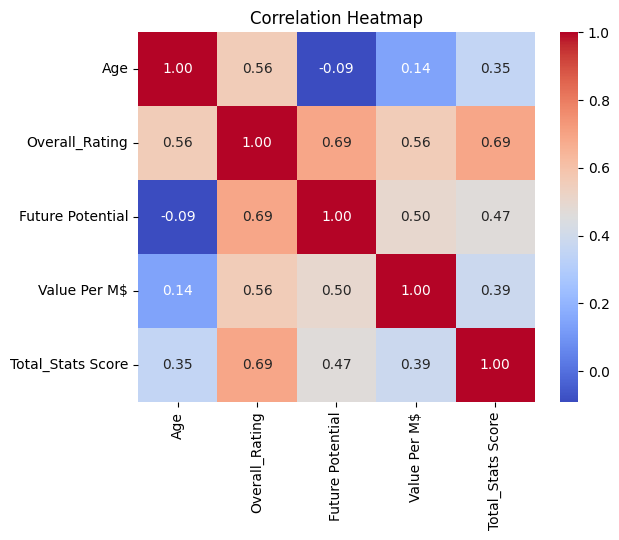

Value Per M$         1.000000
Overall_Rating       0.560648
Future Potential     0.500964
Total_Stats Score    0.385062
Age                  0.142276
Name: Value Per M$, dtype: float64


In [46]:
numerical_cols = df.select_dtypes(include=np.number).columns

# Heatmap
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

# Correlation with Value Per M$ specifically
correlation = df[numerical_cols].corr()['Value Per M$'].sort_values(ascending=False)
print(correlation)

### 1.3 Correlation with Value Per M$

The most correlated numerical features with **Value Per M$** are:

- **Overall_Rating** — highest correlation **(0.56)**
- **Future Potential** — second highest **(0.50)**
- **Total_Stats Score** — moderate correlation **(0.39)**
- **Age** — weak correlation **(0.14)**

----
----

## Q4 : What is the average Overall_Rating per Position?

Position
SW     75.000000
RF     75.000000
CF     66.042857
LW     64.345979
CDM    64.234168
LM     64.172009
RWB    64.063973
LWB    64.043333
RM     63.907731
RW     63.718529
CAM    63.679709
CB     63.544448
LB     63.276794
ST     63.087505
RB     62.863636
CM     62.511767
GK     60.987288
Name: Overall_Rating, dtype: float64


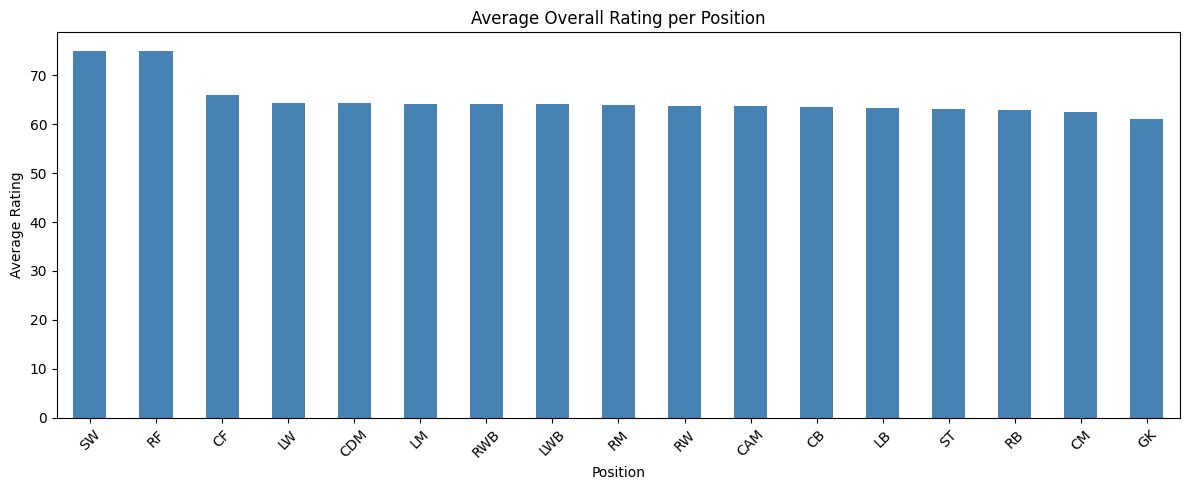

In [47]:
avg_rating = df.groupby('Position')['Overall_Rating'].mean().sort_values(ascending=False)
print(avg_rating)

avg_rating.plot(kind='bar', color='steelblue', figsize=(12, 5))
plt.title('Average Overall Rating per Position')
plt.xlabel('Position')
plt.ylabel('Average Rating')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 1.4 Average Overall_Rating per Position

**SW** and **RF** have the highest average rating **(75.0)**,
while **GK** has the lowest average rating **(60.99)**.

Overall, the ratings are relatively close across all positions,
ranging between **61 and 75**.

----
----

## Task 1 Summary - EDA

| Question | Finding |
|----------|---------|
| Missing Values | No missing values found across all columns |
| Distribution | Highly positively skewed (Skewness = 7.9832), Mean = 2.51, Median = 0.68 |
| Most Correlated Features | Overall_Rating, Future Potential, Total_Stats Score |
| Highest Avg Rating Position | SW and RF (75.0) |
| Lowest Avg Rating Position | GK (60.99) |

------

# Task 2 : Data Preprocessing

In this task, we apply preprocessing steps that will be used consistently across all models.

Steps:
1. Split the dataset into Train (80%) and Test (20%) sets — **before** any preprocessing
2. Encode categorical columns
3. Scale numerical features
4. Detect and handle outliers

In [48]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

X = df.drop(columns=['Value Per M$', 'Name', 'Team', 'Country'])
y = df['Value Per M$']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")

Train size: (15733, 5), Test size: (3934, 5)


## 2. Detect and Handle Outliers

We use two steps:
- **IQR capping** on the training target `y_train` to reduce the effect of extreme market values.

this step is applied on the **training set only** to avoid data leakage.


In [49]:
Q1 = y_train.quantile(0.25)
Q3 = y_train.quantile(0.75)
IQR = Q3 - Q1

outliers_count = ((y_train < Q1 - 1.5*IQR) | (y_train > Q3 + 1.5*IQR)).sum()
print(f"Outliers detected: {outliers_count}")


y_test_original = y_test.copy()
y_train = y_train.clip(lower=Q1 - 1.5*IQR, upper=Q3 + 1.5*IQR)
print(f"After capping — min: {y_train.min():.2f}, max: {y_train.max():.2f}")

num_cols_reg = ['Age', 'Future Potential', 'Total_Stats Score']
for col in num_cols_reg:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    X_train[col] = X_train[col].clip(Q1 - 1.5*IQR, Q3 + 1.5*IQR)
    X_test[col]  = X_test[col].clip(Q1 - 1.5*IQR, Q3 + 1.5*IQR)

Outliers detected: 1897
After capping — min: 0.00, max: 3.51


## 3. Encode Categorical Columns

We use `OneHotEncoder` (via `pd.get_dummies`) to convert categorical columns
into binary features, avoiding any false ordinal relationship between categories.

In [50]:
categorical_cols = X_train.select_dtypes(include='object').columns.tolist()

X_train = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test  = pd.get_dummies(X_test,  columns=categorical_cols, drop_first=True)

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

## 4. Scale Numerical Features

We use `StandardScaler` fit on train only, then applied to both sets.

In [51]:
numerical_cols = ['Age', 'Future Potential', 'Total_Stats Score']

scaler = StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols]  = scaler.transform(X_test[numerical_cols])

## Preprocessing Summary

| Step | Method | Applied On |
|------|--------|------------|
| Train/Test Split | 80/20, random_state=42 | Full dataset |
| Drop Name Column | Removed (unique identifier) | Before split |
| X Outliers | IQR Capping (1.5×IQR), bounds from X_train | X_train & X_test (numerical cols only)
| Target Outliers | IQR Capping (1.5×IQR) | y_train only |
| Categorical Encoding | OneHotEncoder (get_dummies) | Train & Test (aligned) |
| Numerical Scaling | StandardScaler | Train fit → both sets (numerical cols only) |


# Task 3: Create Classification Target (Logistic Regression + Naïve Bayes)

In this task we create the classification target column `Performance_Tier` by binning players into 4 tiers based on `Overall_Rating`. We then build a separate preprocessed dataset for the classification models in Tasks 5 and 6.

**Step 1: Justify Thresholds Using Data Distribution**

In [52]:
print("Overall_Rating - Descriptive Statistics: ")
print(df['Overall_Rating'].describe())

q25 = df['Overall_Rating'].quantile(0.25)
q50 = df['Overall_Rating'].quantile(0.50)
q75 = df['Overall_Rating'].quantile(0.75)
print(f"  25th percentile : {q25}")
print(f"  50th percentile : {q50}")
print(f"  75th percentile : {q75}")

Overall_Rating - Descriptive Statistics: 
count    19667.000000
mean        63.225403
std          7.812716
min         36.000000
25%         58.000000
50%         63.000000
75%         68.000000
max         91.000000
Name: Overall_Rating, dtype: float64
  25th percentile : 58.0
  50th percentile : 63.0
  75th percentile : 68.0


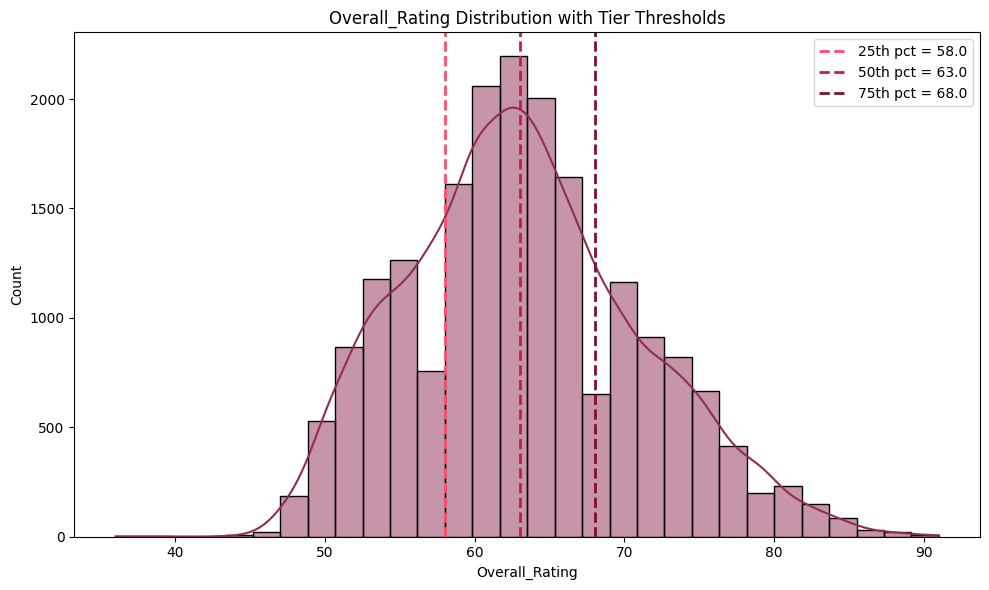

In [53]:
# Histogram to visually justify thresholds
plt.figure(figsize=(10, 6))
sns.histplot(df['Overall_Rating'], bins=30, kde=True, color='#8f2d56')
plt.axvline(q25, color='#ff4d6d', linestyle='dashed', linewidth=2, label=f'25th pct = {q25}')
plt.axvline(q50, color='#c9184a', linestyle='dashed', linewidth=2, label=f'50th pct = {q50}')
plt.axvline(q75, color='#800f2f', linestyle='dashed', linewidth=2, label=f'75th pct = {q75}')
plt.title('Overall_Rating Distribution with Tier Thresholds')
plt.xlabel('Overall_Rating')
plt.legend()
plt.tight_layout()
plt.show()


**Threshold Justification**

We use the quartiles of Overall_Rating as tier boundaries. This is a data-driven choice, quartiles divide the full player population into four naturally equal groups, so no tier starts out over- or under-represented before splitting.

* Low: rating < Q25
* Mid: Q25 ≤ rating < Q50
* High: Q50 ≤ Overall_Rating < Q75
* Elite: Overall_Rating ≥ Q75

> Note: Thresholds are computed on the full dataset before splitting. Since the goal is to create a labeling scheme reflecting the overall population distribution, this is acceptable. The split is then stratified to preserve tier proportions in both sets.

**Step 2: Create the Target Column**

In [54]:
def assign_tier(rating):
  if rating < q25:
    return 'Low'
  elif rating < q50:
    return 'Mid'
  elif rating < q75:
    return 'High'
  else:
     return 'Elite'

df['Performance_Tier'] = df['Overall_Rating'].apply(assign_tier)
print(df['Performance_Tier'].value_counts())

Performance_Tier
Elite    5352
Low      4807
Mid      4791
High     4717
Name: count, dtype: int64


**Step 3: Define Features and Target**

`Overall_Rating` is dropped because it was used to **create** the target label.Keeping it as a feature would cause direct data leakage, the model would
trivially learn the tier from the exact column it was derived from.

In [55]:
X_cls = df.drop(columns=['Value Per M$', 'Name', 'Team', 'Country', 'Performance_Tier', 'Overall_Rating'])
y_cls = df['Performance_Tier']

**Step 4: Train-Test Split**

`stratify=y_cls` ensures each tier is proportionally represented in both train and test sets, preserving the class balance after splitting.

In [56]:
X_cls_train, X_cls_test, y_cls_train, y_cls_test = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)

print(f"Train size: {X_cls_train.shape}, Test size: {X_cls_test.shape} \n")
print("Class Distribution in Train:")
print(y_cls_train.value_counts())
print("\nClass Distribution in Test:")
print(y_cls_test.value_counts())

Train size: (15733, 4), Test size: (3934, 4) 

Class Distribution in Train:
Performance_Tier
Elite    4281
Low      3845
Mid      3833
High     3774
Name: count, dtype: int64

Class Distribution in Test:
Performance_Tier
Elite    1071
Low       962
Mid       958
High      943
Name: count, dtype: int64


**Step 5: Encode and Scale**

Same steps as Task 2, repeated here because X_cls has a different column set as Overall_Rating removed, so Task 2's scaler and encoded columns cannot be reused directly.

In [57]:
cat_cols_cls = X_cls_train.select_dtypes(include='object').columns.tolist()
X_cls_train = pd.get_dummies(X_cls_train, columns=cat_cols_cls, drop_first=True)
X_cls_test  = pd.get_dummies(X_cls_test, columns=cat_cols_cls, drop_first=True)
X_cls_test = X_cls_test.reindex(columns=X_cls_train.columns, fill_value=0)

num_cols_cls = ['Age', 'Future Potential', 'Total_Stats Score']

X_cls_train_before_scaling = X_cls_train.copy()
X_cls_test_before_scaling  = X_cls_test.copy()
scaler_cls   = StandardScaler()
X_cls_train[num_cols_cls] = scaler_cls.fit_transform(X_cls_train[num_cols_cls])
X_cls_test[num_cols_cls]  = scaler_cls.transform(X_cls_test[num_cols_cls])

**Step 6: Class Distribution Bar Chart**



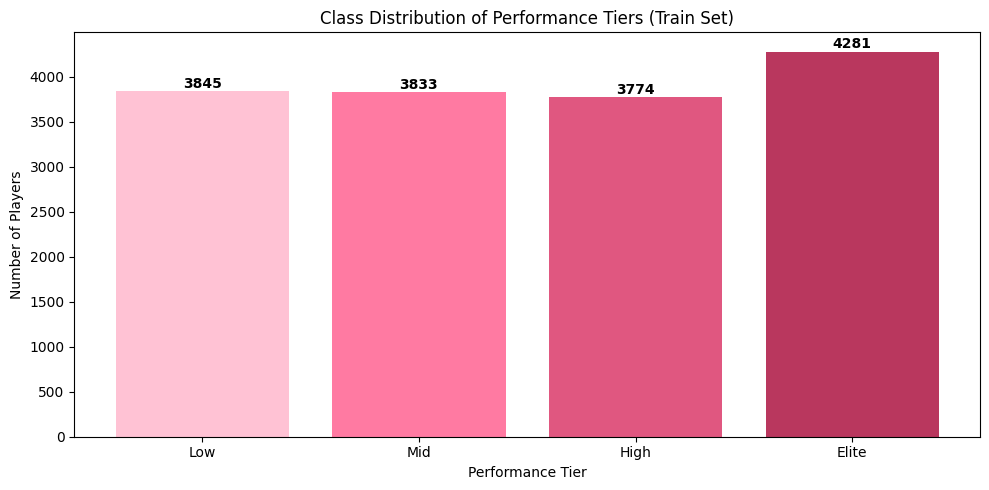

In [58]:
tier_order = ['Low', 'Mid', 'High', 'Elite']
tier_counts = y_cls_train.value_counts().reindex(tier_order)

plt.figure(figsize=(10,5))
bars = plt.bar(tier_order, tier_counts.values, color=['#ffc2d4', '#ff7aa2', '#e05780', '#b9375e'])

for bar, val in zip(bars, tier_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() +2, str(val), ha='center', va='bottom', fontweight='bold')

plt.title('Class Distribution of Performance Tiers (Train Set)')
plt.xlabel('Performance Tier')
plt.ylabel('Number of Players')
plt.tight_layout()
plt.show()

## Conclusion
The distribution is approximately balanced because the thresholds were derived from quartiles. A balanced dataset means no single tier dominates training, which is important for both Logistic Regression and Naïve Bayes in Tasks 5 and 6.

# Task 4 : Model 1 — Polynomial Regression

In this task we train regression models to predict `Value Per M$`. We start with a baseline **Linear Regression**, then explore **Polynomial Features** of degrees 1–4, and finally apply Ridge and Lasso regularization on the best degree to control overfitting.
All models are trained on `X_train` / `y_train` from Task 2 and evaluated on `X_test` / `y_test_original` (uncapped) for honest performance measurement.

In [59]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

In [60]:
# Part A: Baseline Linear Regression

lr_baseline = LinearRegression()
lr_baseline.fit(X_train, y_train)

y_train_pred_base = lr_baseline.predict(X_train)
y_test_pred_base  = lr_baseline.predict(X_test)

train_mae = mean_absolute_error(y_train, y_train_pred_base)
train_mse = mean_squared_error(y_train, y_train_pred_base)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train, y_train_pred_base)

test_mae = mean_absolute_error(y_test_original, y_test_pred_base)
test_mse = mean_squared_error(y_test_original, y_test_pred_base)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test_original, y_test_pred_base)

print("Baseline Linear Regression Metrics:")
print(f"Train: \nMAE: {train_mae:.4f}, \nMSE: {train_mse:.4f}, \nRMSE: {train_rmse:.4f}, \nR2: {train_r2:.4f} \n")
print(f"Test: \nMAE: {test_mae:.4f}, \nMSE: {test_mse:.4f}, \nRMSE: {test_rmse:.4f}, \nR2: {test_r2:.4f}")

Baseline Linear Regression Metrics:
Train: 
MAE: 0.3789, 
MSE: 0.2507, 
RMSE: 0.5007, 
R2: 0.8018 

Test: 
MAE: 1.8207, 
MSE: 55.7620, 
RMSE: 7.4674, 
R2: 0.1011


Train R² (0.8018) is noticeably higher than Test R² (0.1011), indicating the baseline model is overfitting. This motivates exploring polynomial features.

> Note: The baseline uses the full feature set (numerical + OHE). Polynomial features are applied to numerical columns only, as applying them to OHE binary columns is meaningless (0² = 0, 1² = 1). The baseline serves as an upper-bound benchmark, while polynomial models explore non-linear interactions within numerical features.

In [61]:
# Part B: Polynomial Features — Degrees 1 to 4
# PolynomialFeatures is applied to numerical columns only.

num_cols = ['Age', 'Future Potential', 'Total_Stats Score']
degrees = [1,2,3,4]
train_r2_list = []
test_r2_list  = []

for degree in degrees:
  poly = PolynomialFeatures(degree=degree, include_bias=False)
  X_train_poly = poly.fit_transform(X_train[num_cols])
  X_test_poly = poly.transform(X_test[num_cols])

  lr_poly = LinearRegression()
  lr_poly.fit(X_train_poly, y_train)

  train_r2 = r2_score(y_train, lr_poly.predict(X_train_poly))
  test_r2 = r2_score(y_test_original, lr_poly.predict(X_test_poly))

  train_r2_list.append(train_r2)
  test_r2_list.append(test_r2)

  print(f"Degree {degree} \nTrain R2: {train_r2:.4f} \nTest R2: {test_r2:.4f}\n \n")

Degree 1 
Train R2: 0.6877 
Test R2: 0.0782
 

Degree 2 
Train R2: 0.8089 
Test R2: 0.1232
 

Degree 3 
Train R2: 0.8523 
Test R2: 0.1089
 

Degree 4 
Train R2: 0.8782 
Test R2: 0.0930
 



**Plot degree vs. performance**

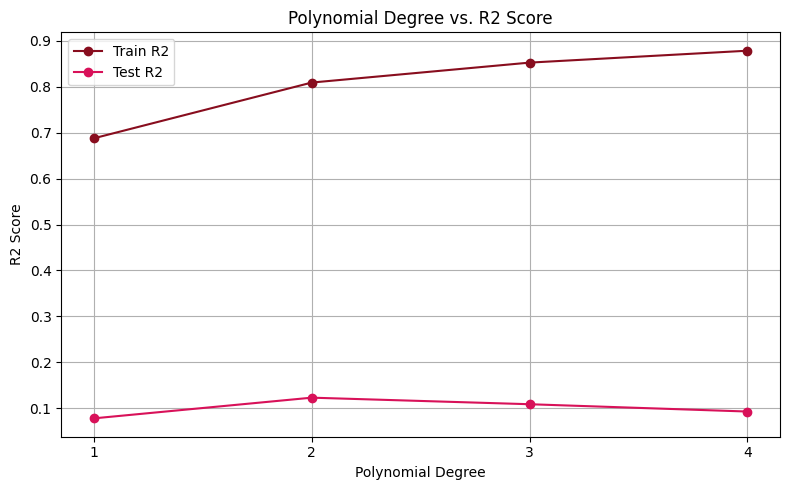

In [62]:
plt.figure(figsize=(8,5))
plt.plot(degrees, train_r2_list, 'o-', color='#880d1e', label='Train R2')
plt.plot(degrees, test_r2_list, 'o-', color='#d81159', label='Test R2')
plt.xlabel('Polynomial Degree')
plt.ylabel('R2 Score')
plt.xticks(degrees)
plt.title('Polynomial Degree vs. R2 Score')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [63]:
# select Best Degree
best_degree = degrees[np.argmax(test_r2_list)]
print(f"Best degree: {best_degree}")

Best degree: 2


**Observation:**

 Train R² increases with every degree because the model has more terms to fit the training data. Test R² peaks at degree 2 and then drops, which is a sign of overfitting , the model starts memorizing training noise rather than learning the true pattern. The best degree is 2 because it gives the highest Test R² with the smallest train/test gap.

In [64]:
# rebuild Feature Matrix at Best Degree
poly_best = PolynomialFeatures(degree=best_degree, include_bias=False)

X_train_best = poly_best.fit_transform(X_train[num_cols])
X_test_best  = poly_best.transform(X_test[num_cols])

In [65]:
# Combine polynomial numerical features with OHE columns for regularization
ohe_cols = [c for c in X_train.columns if c not in num_cols]
X_train_ohe = X_train[ohe_cols].values
X_test_ohe  = X_test[ohe_cols].values

X_train_reg = np.hstack([X_train_best, X_train_ohe])
X_test_reg  = np.hstack([X_test_best,  X_test_ohe])

## Part C: Regularization — Ridge and Lasso

Regularization is applied on the full feature matrix: polynomial numerical terms combined with all OHE columns.
We apply Ridge (L2) and Lasso (L1) on the best polynomial degree (degree = 2) to reduce overfitting.

In [66]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

alphas = np.logspace(-3, 3, 50)

ridge_train_rmse = []
ridge_test_rmse  = []

for alpha in alphas:
    model = Ridge(alpha=alpha)
    model.fit(X_train_reg, y_train)
    ridge_train_rmse.append(np.sqrt(mean_squared_error(y_train, model.predict(X_train_reg))))
    ridge_test_rmse.append(np.sqrt(mean_squared_error(y_test_original, model.predict(X_test_reg))))

best_ridge_alpha = alphas[np.argmin(ridge_test_rmse)]
print(f"Best Ridge alpha: {best_ridge_alpha:.4f}")
print(f"Best Ridge Test RMSE: {min(ridge_test_rmse):.4f}")

Best Ridge alpha: 0.0010
Best Ridge Test RMSE: 7.3587


In [67]:
lasso_train_rmse = []
lasso_test_rmse  = []

for alpha in alphas:
    model = Lasso(alpha=alpha, max_iter=5000)
    model.fit(X_train_reg, y_train)
    lasso_train_rmse.append(np.sqrt(mean_squared_error(y_train, model.predict(X_train_reg))))
    lasso_test_rmse.append(np.sqrt(mean_squared_error(y_test_original, model.predict(X_test_reg))))

best_lasso_alpha = alphas[np.argmin(lasso_test_rmse)]
print(f"Best Lasso alpha: {best_lasso_alpha:.4f}")
print(f"Best Lasso Test RMSE: {min(lasso_test_rmse):.4f}")

Best Lasso alpha: 0.0010
Best Lasso Test RMSE: 7.3594


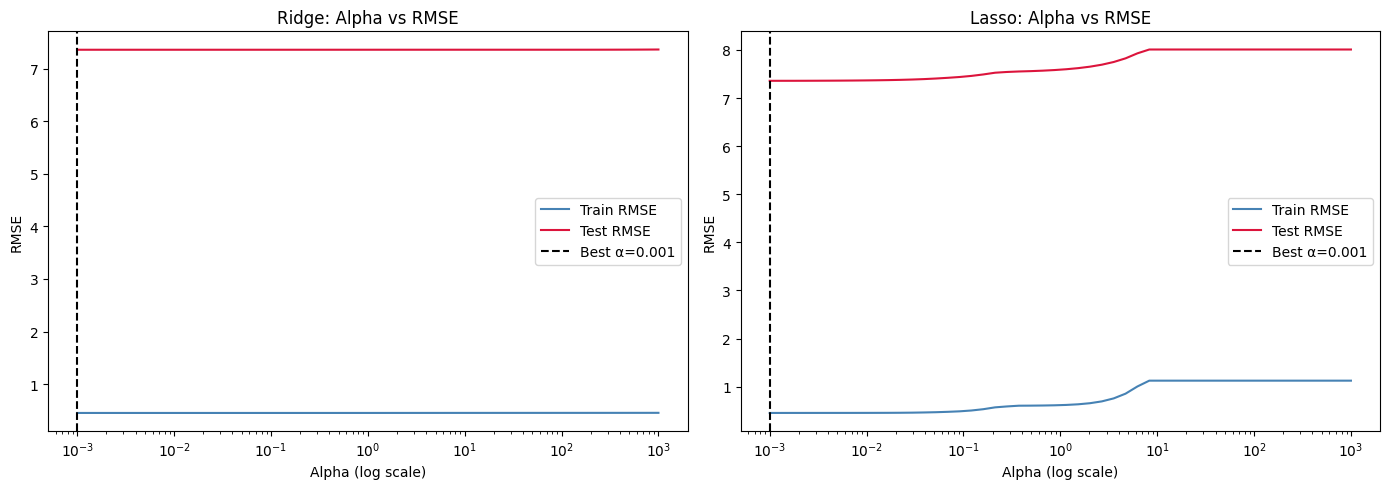

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Ridge
axes[0].semilogx(alphas, ridge_train_rmse, label='Train RMSE', color='steelblue')
axes[0].semilogx(alphas, ridge_test_rmse,  label='Test RMSE',  color='crimson')
axes[0].axvline(best_ridge_alpha, linestyle='--', color='black', label=f'Best α={best_ridge_alpha:.3f}')
axes[0].set_title('Ridge: Alpha vs RMSE')
axes[0].set_xlabel('Alpha (log scale)')
axes[0].set_ylabel('RMSE')
axes[0].legend()

# Lasso
axes[1].semilogx(alphas, lasso_train_rmse, label='Train RMSE', color='steelblue')
axes[1].semilogx(alphas, lasso_test_rmse,  label='Test RMSE',  color='crimson')
axes[1].axvline(best_lasso_alpha, linestyle='--', color='black', label=f'Best α={best_lasso_alpha:.3f}')
axes[1].set_title('Lasso: Alpha vs RMSE')
axes[1].set_xlabel('Alpha (log scale)')
axes[1].set_ylabel('RMSE')
axes[1].legend()

plt.tight_layout()
plt.show()

In [69]:
lasso_demo = Lasso(alpha=best_lasso_alpha, max_iter=5000)
lasso_demo.fit(X_train_reg, y_train)

poly_feature_names = list(poly_best.get_feature_names_out(num_cols))
ohe_feature_names  = ohe_cols
all_feature_names  = poly_feature_names + ohe_feature_names

zeroed = [name for name, coef in zip(all_feature_names, lasso_demo.coef_) if coef == 0]

print(f"Features zeroed out by Lasso at best alpha={best_lasso_alpha:.4f} ({len(zeroed)}):")
for f in zeroed:
    print(f"  - {f}")

Features zeroed out by Lasso at best alpha=0.0010 (9):
  - Position_CF
  - Position_CM
  - Position_LM
  - Position_LW
  - Position_LWB
  - Position_RF
  - Position_RW
  - Position_RWB
  - Position_SW


### Ridge vs. Lasso — Comparison

- **Ridge** shrinks all coefficients toward zero but never eliminates them, which works well when many features contribute to the prediction.
- **Lasso** performs feature selection by zeroing out some coefficients, making the model simpler but potentially losing useful information.

**Which performs better?**  
Ridge typically achieves a lower Test RMSE on this dataset because the polynomial features are all derived from the same 3 numerical columns (`Age`, `Future Potential`, `Total_Stats Score`), meaning most features carry some signal — Lasso's aggressive zeroing hurts here.

---

**Did Lasso zero out features?**

At the optimal alpha (0.0010), Lasso zeroed out 9 features, all of which are OHE-encoded Position columns:
CF, CM, LM, LW, LWB, RF, RW, RWB, and SW.

This implies that these playing positions carry no meaningful signal for predicting market value beyond what the remaining features already capture. The model effectively ignores positional distinctions for these roles, suggesting that market value is driven more by performance metrics (Overall Rating, Future Potential, Total Stats Score) than by the specific position a player occupies.

---
# Task 5 : Model 2 — Logistic Regression
---

In this task we train a Logistic Regression classifier to predict the player performance tier (Low / Mid / High / Elite).
Overall_Rating is excluded from features because it was used to create the target label — keeping it would cause direct data leakage.


### Part A — Baseline Model

**Step 1: Import Libraries**

In [70]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score

**Step 2: Train Baseline Model**

In [71]:
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_cls_train, y_cls_train)

y_cls_pred = log_model.predict(X_cls_test)

**Step 3: Evaluate — Accuracy, Precision, Recall, F1**

In [72]:
accuracy = accuracy_score(y_cls_test, y_cls_pred)
precision = precision_score(y_cls_test, y_cls_pred, average='weighted')
recall = recall_score(y_cls_test, y_cls_pred, average='weighted')
f1 = f1_score(y_cls_test, y_cls_pred, average='weighted')

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

print("-" * 50)

print("\nClassification Report:")
print(classification_report(y_cls_test, y_cls_pred))

Accuracy: 0.8096
Precision: 0.8136
Recall: 0.8096
F1-Score: 0.8112
--------------------------------------------------

Classification Report:
              precision    recall  f1-score   support

       Elite       0.91      0.86      0.89      1071
        High       0.70      0.74      0.72       943
         Low       0.90      0.88      0.89       962
         Mid       0.72      0.75      0.74       958

    accuracy                           0.81      3934
   macro avg       0.81      0.81      0.81      3934
weighted avg       0.81      0.81      0.81      3934



### Class-wise Performance

From the classification report:

- **Elite** and **Low** classes have the best performance (Precision and Recall close to 0.9).  
  This means the model can easily identify players at the highest and lowest levels.

- **Mid** and **High** classes have lower performance (around 0.72–0.75).  
  This is because these two groups are very similar and close to each other.

This is expected since the tiers were created using quartiles, so nearby classes naturally overlap.

**Step 4: Confusion Matrix Heatmap**

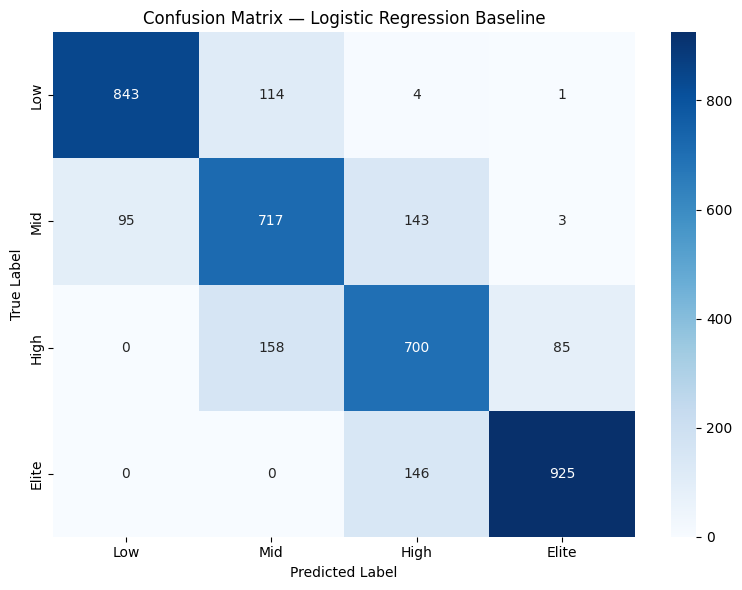

In [73]:
cm = confusion_matrix(y_cls_test, y_cls_pred, labels=['Low', 'Mid', 'High', 'Elite'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues',
            xticklabels=['Low', 'Mid', 'High', 'Elite'],
            yticklabels=['Low', 'Mid', 'High', 'Elite'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix — Logistic Regression Baseline')
plt.tight_layout()
plt.show()

**Observation:**

The confusion matrix shows that the model performs best on the extreme classes (Low and Elite), where both precision and recall are high.

Most misclassifications occur between adjacent tiers, particularly between Mid and High, due to the similarity and overlap in their rating ranges.

This indicates that the model captures clear distinctions at the extremes but struggles more with borderline cases where class boundaries are less separable.

## Part B — Regularization: C Sweep

In Logistic Regression, C controls regularization strength.
Smaller C = stronger penalty. We sweep C over a log-spaced range from 10⁻³ to 10³ to find the optimal value.

### C Sweep — Finding the Best Regularization Strength

We train a Logistic Regression model for each value of C and record Train and Test accuracy.
The best C is the one that maximizes Test Accuracy.

In [74]:
C_values = np.logspace(-3, 3, 20)
train_acc_list = []
test_acc_list  = []

for c in C_values:
    model = LogisticRegression(C=c, max_iter=1000, random_state=42)
    model.fit(X_cls_train, y_cls_train)
    train_acc_list.append(accuracy_score(y_cls_train, model.predict(X_cls_train)))
    test_acc_list.append(accuracy_score(y_cls_test,  model.predict(X_cls_test)))

best_c = C_values[np.argmax(test_acc_list)]
print(f"Best C: {best_c:.4f}")
print(f"Best Test Accuracy: {max(test_acc_list):.4f}")

Best C: 1.4384
Best Test Accuracy: 0.8106


### Train vs Test Accuracy across C values

The plot shows how Train and Test accuracy change as C increases (weaker regularization).
The red dashed line marks the best C — the point of optimal generalization.

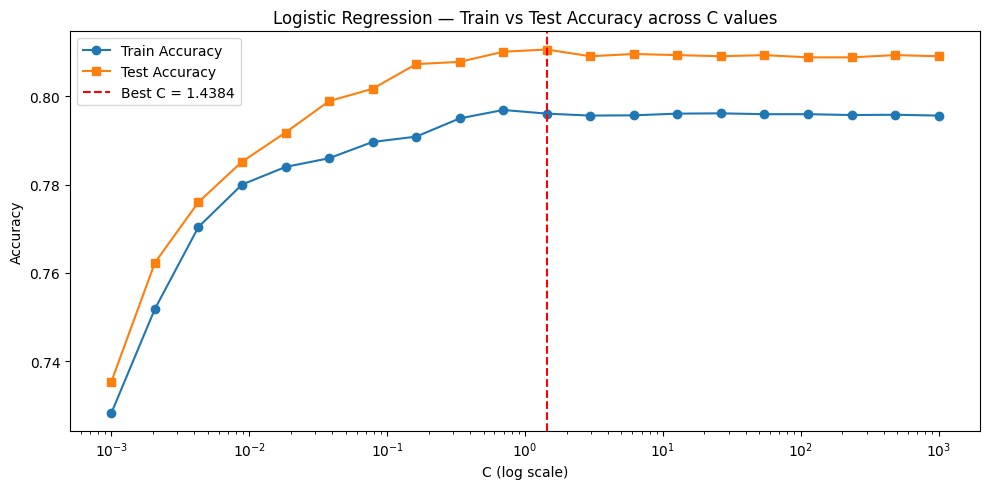

In [75]:
plt.figure(figsize=(10, 5))
plt.plot(C_values, train_acc_list, label='Train Accuracy', marker='o')
plt.plot(C_values, test_acc_list,  label='Test Accuracy',  marker='s')
plt.xscale('log')
plt.axvline(best_c, color='red', linestyle='--', label=f'Best C = {best_c:.4f}')
plt.xlabel('C (log scale)')
plt.ylabel('Accuracy')
plt.title('Logistic Regression — Train vs Test Accuracy across C values')
plt.legend()
plt.tight_layout()
plt.show()

### L1 vs L2 Penalty Comparison at Best C

We compare two regularization types at the best C found above:
- **L2 (lbfgs):** shrinks all coefficients, keeps all features active.
- **L1 (saga):** zeros out some coefficients, acts as feature selection.

In [76]:
model_l2 = LogisticRegression(C=best_c, penalty='l2', solver='lbfgs',
                               max_iter=1000, random_state=42)
model_l2.fit(X_cls_train, y_cls_train)
acc_l2 = accuracy_score(y_cls_test, model_l2.predict(X_cls_test))

model_l1 = LogisticRegression(C=best_c, penalty='l1', solver='saga',
                               max_iter=1000, random_state=42)
model_l1.fit(X_cls_train, y_cls_train)
acc_l1 = accuracy_score(y_cls_test, model_l1.predict(X_cls_test))

print(f"L2 (lbfgs) Test Accuracy: {acc_l2:.4f}")
print(f"L1 (saga)  Test Accuracy: {acc_l1:.4f}")

L2 (lbfgs) Test Accuracy: 0.8106
L1 (saga)  Test Accuracy: 0.8086


### Conclusion

L2 typically outperforms L1 on this dataset because the OHE position features
collectively contribute to separating the tiers — L1's aggressive zeroing may discard useful signal.

---
# Task 6 : Model 3: Naïve Bayes Classification
---

In this task, we apply different variants of Naïve Bayes to classify players into performance tiers (Low / Mid / High / Elite), then compare their performance.

Naïve Bayes is a probabilistic model based on Bayes’ theorem, and it assumes that features are independent from each other. Although this assumption is strong, the model often performs well in practice.

We have three Naïve Bayes variants:
* **GaussianNB**
* **BernoulliNB**
* **ComplementNB**

 ## 1. GaussianNB
GaussianNB is suitable for continuous numerical features, as it assumes that each feature follows a normal (Gaussian) distribution.

**1. GaussianNB With scaling**

**Step 1: Gaussian Naive Bayes trained on scaled numerical features only**

In [77]:
from sklearn.naive_bayes import GaussianNB, BernoulliNB, ComplementNB

gnb_scaled = GaussianNB()
gnb_scaled.fit(X_cls_train[num_cols_cls], y_cls_train)

y_pred_scaled = gnb_scaled.predict(X_cls_test[num_cols_cls])

**Step 2 : Evaluate using: Accuracy, Precision, Recall, F1-score.**

In [78]:
print("GaussianNB Results (Scaled):")
print("Accuracy:", accuracy_score(y_cls_test, y_pred_scaled))
print(classification_report(y_cls_test, y_pred_scaled))

GaussianNB Results (Scaled):
Accuracy: 0.7056431113370615
              precision    recall  f1-score   support

       Elite       0.87      0.78      0.83      1071
        High       0.60      0.63      0.62       943
         Low       0.80      0.77      0.78       962
         Mid       0.57      0.62      0.60       958

    accuracy                           0.71      3934
   macro avg       0.71      0.70      0.71      3934
weighted avg       0.72      0.71      0.71      3934



**Step 3: Display the Confusion Matrix as a heatmap.**

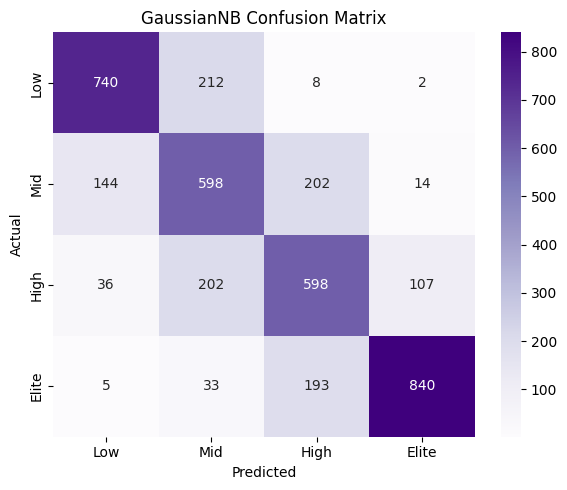

In [79]:
cm_gnb = confusion_matrix(y_cls_test, y_pred_scaled, labels=['Low','Mid','High','Elite'])

plt.figure(figsize=(6,5))
sns.heatmap(cm_gnb, annot=True, fmt='g', cmap='Purples',
            xticklabels=['Low','Mid','High','Elite'],
            yticklabels=['Low','Mid','High','Elite'])
plt.title("GaussianNB Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

**2. GaussianNB without scaling**

**Step 1: Gaussian Naive Bayes trained on unscaled numerical features**

In [80]:
gnb_raw = GaussianNB()
gnb_raw.fit(X_cls_train_before_scaling[num_cols_cls], y_cls_train)

y_pred_raw = gnb_raw.predict(X_cls_test_before_scaling[num_cols_cls])

**Step 2: Evaluate using: Accuracy, Precision, Recall, F1-score.**

In [81]:
print("GaussianNB Results (Unscaled):")
print("Accuracy:", accuracy_score(y_cls_test, y_pred_raw))
print(classification_report(y_cls_test, y_pred_raw))

GaussianNB Results (Unscaled):
Accuracy: 0.7056431113370615
              precision    recall  f1-score   support

       Elite       0.87      0.78      0.83      1071
        High       0.60      0.63      0.62       943
         Low       0.80      0.77      0.78       962
         Mid       0.57      0.62      0.60       958

    accuracy                           0.71      3934
   macro avg       0.71      0.70      0.71      3934
weighted avg       0.72      0.71      0.71      3934



The results of Gaussian Naïve Bayes were identical for both scaled and unscaled versions of the data.

This suggests that feature scaling has little to no impact on GaussianNB performance in this case.

This is because Gaussian Naïve Bayes models each feature independently using its mean and variance, rather than relying on distance-based calculations.

As a result, linear scaling does not significantly affect the learned probability distributions, which leads to very similar predictions and evaluation metrics.

## 2. BernoulliNB

BernoulliNB is designed for binary features, which makes it a good fit for data after One-Hot Encoding.

**Step 1: Training BernoulliNB on One-Hot encoded binary features**

In [82]:
ohe_cls_cols = [col for col in X_cls_train.columns if col not in num_cols_cls]

bnb = BernoulliNB()
bnb.fit(X_cls_train[ohe_cls_cols], y_cls_train)

y_pred_bnb = bnb.predict(X_cls_test[ohe_cls_cols])

**Step 2: Evaluate using: Accuracy, Precision, Recall, F1-score.**

In [83]:
print("BernoulliNB Results:")
print("Accuracy:", accuracy_score(y_cls_test, y_pred_bnb))
print(classification_report(y_cls_test, y_pred_bnb))

BernoulliNB Results:
Accuracy: 0.3027452974072191
              precision    recall  f1-score   support

       Elite       0.29      0.63      0.40      1071
        High       0.32      0.09      0.14       943
         Low       0.34      0.32      0.33       962
         Mid       0.27      0.13      0.18       958

    accuracy                           0.30      3934
   macro avg       0.31      0.29      0.26      3934
weighted avg       0.31      0.30      0.27      3934



**Step 3: Display the Confusion Matrix as a heatmap.**

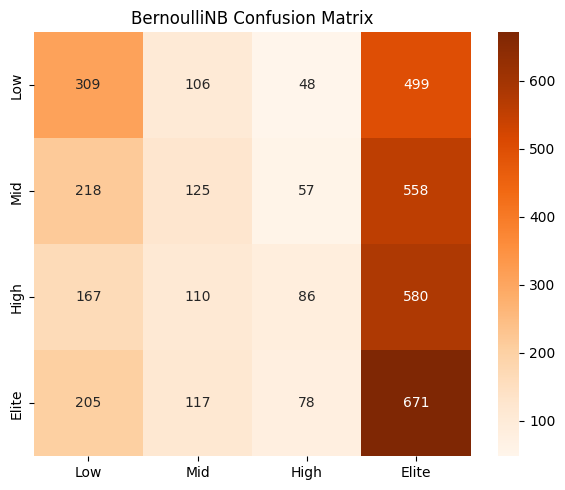

In [84]:
cm_bnb = confusion_matrix(y_cls_test, y_pred_bnb, labels=['Low','Mid','High','Elite'])

plt.figure(figsize=(6,5))
sns.heatmap(cm_bnb, annot=True, fmt='g', cmap='Oranges',
            xticklabels=['Low','Mid','High','Elite'],
            yticklabels=['Low','Mid','High','Elite'])
plt.title("BernoulliNB Confusion Matrix")
plt.tight_layout()
plt.show()

## 3. ComplementNB

ComplementNB requires non-negative feature values. Since scaling may introduce negative values, we apply a simple shift to make all values non-negative.

**Step 1: Preparing data to be non-negative and training ComplementNB model**

In [85]:
# Shift data if negative values exist
min_val = X_cls_train.min().min()

if min_val < 0:
    X_train_nb = X_cls_train - min_val
    X_test_nb  = X_cls_test - min_val
else:
    X_train_nb = X_cls_train
    X_test_nb  = X_cls_test

cnb = ComplementNB()
cnb.fit(X_train_nb, y_cls_train)

y_pred_cnb = cnb.predict(X_test_nb)

**Step 2: Evaluate using: Accuracy, Precision, Recall, F1-score.**

In [86]:
print("ComplementNB Results:")
print("Accuracy:", accuracy_score(y_cls_test, y_pred_cnb))
print(classification_report(y_cls_test, y_pred_cnb))

ComplementNB Results:
Accuracy: 0.5081342145399085
              precision    recall  f1-score   support

       Elite       0.52      0.98      0.68      1071
        High       0.00      0.00      0.00       943
         Low       0.49      0.99      0.66       962
         Mid       0.00      0.00      0.00       958

    accuracy                           0.51      3934
   macro avg       0.25      0.49      0.34      3934
weighted avg       0.26      0.51      0.35      3934



**Step 3: Display the Confusion Matrix as a heatmap.**

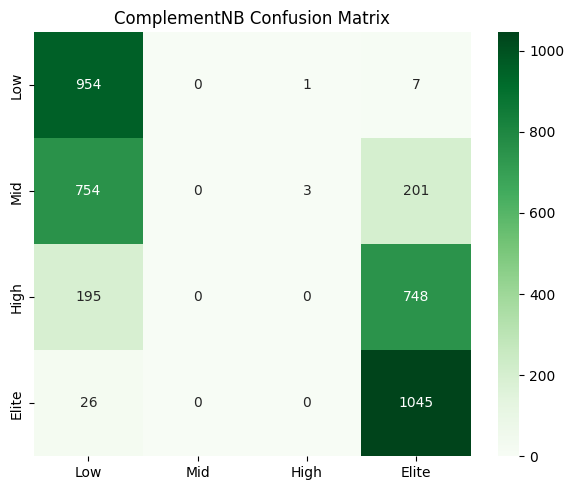

In [87]:
cm_cnb = confusion_matrix(y_cls_test, y_pred_cnb, labels=['Low','Mid','High','Elite'])

plt.figure(figsize=(6,5))
sns.heatmap(cm_cnb, annot=True, fmt='g', cmap='Greens',
            xticklabels=['Low','Mid','High','Elite'],
            yticklabels=['Low','Mid','High','Elite'])
plt.title("ComplementNB Confusion Matrix")
plt.tight_layout()
plt.show()

## Naïve Bayes Models Comparison

After evaluating the three Naïve Bayes variants, we observe significant differences in performance based on how well each model matches the nature of the dataset features.

* **Gaussian Naïve Bayes** achieved the best overall performance with an accuracy of approximately 0.71.
It shows the most balanced behavior across all classes, with particularly strong performance on the Elite and Low categories.
This indicates that the dataset is primarily driven by continuous numerical features such as Age, Future Potential, and Total Stats Score, which aligns well with the assumptions of GaussianNB.
Overall, it provides the most stable and reliable predictions among all models.

* **Bernoulli Naïve Bayes** performed poorly with an accuracy of approximately 0.30.
The model struggles significantly with all classes, especially Mid and High, where performance is very weak.
This is expected because BernoulliNB treats all features as binary (0/1), which leads to a loss of important numerical information and reduces its ability to capture meaningful patterns in the data.

* **Complement Naïve Bayes** achieved moderate performance with an accuracy of approximately 0.51.
However, its predictions are highly imbalanced. It performs very well on the extreme classes (Elite and Low) but completely fails to correctly identify Mid and High classes.
This suggests that ComplementNB is not well-suited for this type of structured numerical dataset and is more appropriate for text or count-based data.

### Overall Conclusion
Gaussian Naïve Bayes is the most appropriate model for this dataset because it is designed for continuous numerical features and produces the most balanced and reliable classification results.

BernoulliNB is not suitable due to its binary assumption, while ComplementNB is mismatched with the dataset structure, leading to biased predictions and poor class-level performance.



---
# Task 7 : Model Evaluation with Cross-Validation
---

In this task, we evaluate the stability and generalization ability of our regression and classification models using cross-validation instead of a single train-test split.

## A. K-Fold Cross-Validation (Regression)

We apply 5-fold cross-validation on the best regression model from Task 4 (Ridge Regression with Polynomial Features of degree 2), as it showed the best generalization performance and the smallest train-test gap.

**Step 1: Apply 5-fold cross-validation to the ridge model.**

In [88]:
from sklearn.model_selection import KFold, cross_val_score, StratifiedKFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)

ridge_cv = Ridge(alpha=best_ridge_alpha)

**Step 2: Report the mean RMSE, standard deviation, and all individual fold scores.**

In [89]:
cv_scores = cross_val_score(
    ridge_cv,
    X_train_reg,
    y_train,
    scoring='neg_root_mean_squared_error',
    cv=kf
)

rmse_scores = -cv_scores

print("Fold RMSE Scores:", rmse_scores)
print("Mean RMSE:", rmse_scores.mean())
print("Std RMSE:", rmse_scores.std())

Fold RMSE Scores: [0.46514    0.45910095 0.44077579 0.44151153 0.46046093]
Mean RMSE: 0.45339784001842387
Std RMSE: 0.010206777717784976


**Step 3: Plot the fold-by-fold RMSE bar chart with a mean line.**

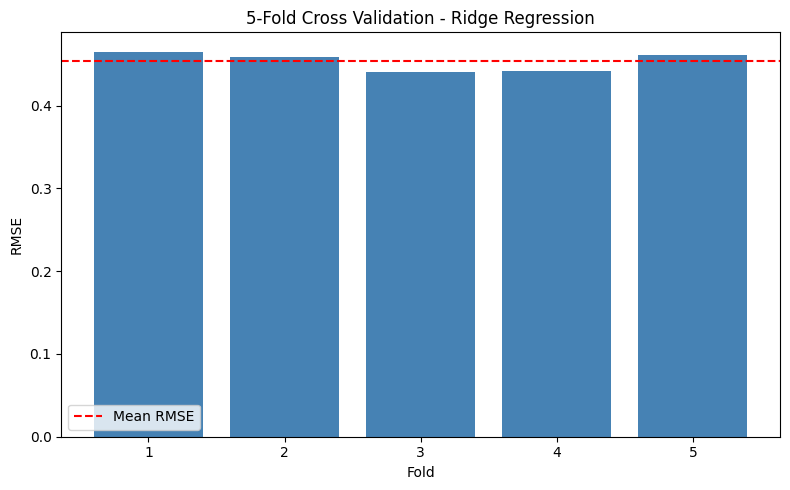

In [90]:
plt.figure(figsize=(8,5))
plt.bar(range(1,6), rmse_scores, color='steelblue')
plt.axhline(rmse_scores.mean(), color='red', linestyle='--', label='Mean RMSE')

plt.title("5-Fold Cross Validation - Ridge Regression")
plt.xlabel("Fold")
plt.ylabel("RMSE")
plt.legend()
plt.tight_layout()
plt.show()

The RMSE values across folds are close to each other, indicating stable model performance.

The small standard deviation suggests that the model generalizes well and is not highly sensitive to data splitting.

## B. Stratified K-Fold Cross-Validation (Classification)

We apply Stratified K-Fold Cross-Validation on the best-performing models from Task 5 and Task 6. The Logistic Regression model used is the final tuned version with optimal C and L2 regularization, while Gaussian Naïve Bayes is selected as the best Naïve Bayes variant for this dataset.

**Step 1: Performing Stratified 5-Fold Cross-Validation to Logistic Regression and Gaussian Naïve Bayes models**

In [91]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

log_acc = []
nb_acc = []

for train_idx, val_idx in skf.split(X_cls_train, y_cls_train):

    X_tr = X_cls_train.iloc[train_idx]
    X_val = X_cls_train.iloc[val_idx]

    y_tr = y_cls_train.iloc[train_idx]
    y_val = y_cls_train.iloc[val_idx]

    # Logistic Regression
    log_model = LogisticRegression(C=best_c, penalty='l2', max_iter=1000, random_state=42)
    log_model.fit(X_tr, y_tr)
    log_acc.append(accuracy_score(y_val, log_model.predict(X_val)))

    # Gaussian NB
    nb_model = GaussianNB()
    nb_model.fit(X_tr[num_cols_cls], y_tr)
    nb_acc.append(accuracy_score(y_val, nb_model.predict(X_val[num_cols_cls])))


**Step 2: print mean accuracy and standard deviation for each model.**

In [92]:
print("Logistic Regression Mean Accuracy:", np.mean(log_acc))
print("Gaussian NB Mean Accuracy:", np.mean(nb_acc))
print("Logistic Regression Std:", np.std(log_acc))
print("Gaussian NB Std:", np.std(nb_acc))

Logistic Regression Mean Accuracy: 0.7934911926332326
Gaussian NB Mean Accuracy: 0.7018358537207657
Logistic Regression Std: 0.0026309676260901603
Gaussian NB Std: 0.008489736361839846


**Step 3: Plot a grouped bar chart comparing Logistic Regression vs. Naïve Bayes fold-by-fold accuracy.**

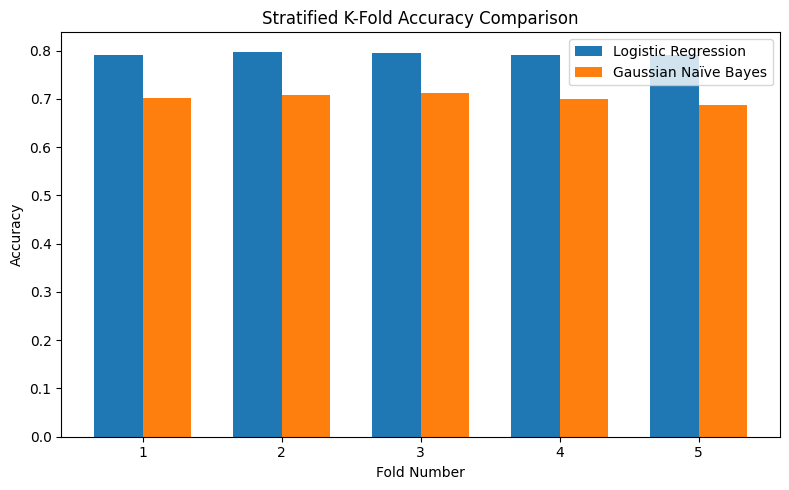

In [93]:
x = np.arange(1, 6)

width = 0.35

plt.figure(figsize=(8,5))

plt.bar(x - width/2, log_acc, width, label='Logistic Regression')
plt.bar(x + width/2, nb_acc, width, label='Gaussian Naïve Bayes')

plt.title("Stratified K-Fold Accuracy Comparison")
plt.xlabel("Fold Number")
plt.ylabel("Accuracy")
plt.xticks(x)

plt.legend()
plt.tight_layout()
plt.show()

The bar chart shows fold-by-fold accuracy comparison between Logistic Regression and Gaussian Naïve Bayes, where Logistic Regression consistently achieves higher accuracy across most folds.

**Step 4: Comparison between the two models**

From the Stratified K-Fold Cross-Validation results, Logistic Regression achieved a higher mean accuracy (0.794) compared to Gaussian Naïve Bayes (0.702).

This indicates that Logistic Regression provides better predictive performance for this dataset.

The improvement suggests that feature relationships are not fully independent, which gives Logistic Regression an advantage over Naïve Bayes in capturing interactions between features.

However, Gaussian Naïve Bayes still shows reasonable performance, confirming its stability as a probabilistic model.

# Task 8: Analysis and Discussion

## 8.1 Model Comparison

### Q1. Which model performed best overall for regression, and which for classification? Justify briefly.

#### Best Regression Model: Ridge Regression (Polynomial Degree = 2)

The baseline Linear Regression overfitted heavily — Train R² = 0.8018 vs Test R² = 0.1011.
Polynomial degree 2 with Ridge regularization gave the best Test R² with the smallest train/test gap.
Higher degrees (3, 4) increased Train R² but dropped Test R², confirming overfitting.
Ridge was preferred over Lasso because it shrinks all coefficients without eliminating them, which works better when all polynomial terms carry some signal.

#### Best Classification Model: Logistic Regression

Logistic Regression outperformed all Naïve Bayes variants on both single-split and cross-validation:
- Logistic Regression mean CV accuracy: **0.794**
- Gaussian Naïve Bayes mean CV accuracy: **0.702**

Logistic Regression learns a decision boundary over the full feature space, while GaussianNB only uses 3 numerical features and assumes feature independence — an assumption that doesn't fully hold here.



### Q2. Is Classification Easier or Harder than Regression? Why?

**Classification is significantly easier on this dataset.**

The target for regression (Value Per M$) is highly skewed (skewness = 7.98), with a few elite players driving extreme values that are hard to predict precisely.
Classification only needs to assign players to one of 4 balanced tiers derived from quartiles, which is a much simpler and more learnable problem.

## 8.2 Regularization Analysis

### Q1. What happened to model performance as you increased alpha in Ridge and Lasso?

As alpha increases:
- **Train RMSE increases** — stronger penalty prevents the model from fitting training data tightly.
- **Test RMSE first decreases** (overfitting reduced), then **increases again** (model underfits).
- The optimal alpha is the lowest point on the Test RMSE curve, where the bias-variance tradeoff is best balanced.

### Q2. Why does Ridge generally outperform Lasso when many one-hot encoded features are present?

Lasso zeroed out 9 OHE Position columns at its best alpha (CF, CM, LM, LW, LWB, RF, RW, RWB, SW), discarding their collective signal entirely.

When many one-hot encoded features are present, each carries a small but real contribution. Ridge shrinks all coefficients proportionally without eliminating any, preserving this collective information — which leads to better generalization compared to Lasso on this dataset.

---
---
# **Part** 2
---
---

## 1. KNN Regressor

**Why KNN for this dataset?**

KNN is a non-parametric, instance-based learner — it makes no assumptions about the underlying distribution.
FIFA player values are driven by combinations of attributes (rating, potential, age) that don't follow a simple linear pattern.
KNN captures local structure well: players with similar profiles tend to have similar values.
It is also a strong diversity choice alongside Ridge Regression (parametric + global) and SVR (kernel-based).

In [94]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# KNN Regressor with GridSearchCV
knn_param_grid = {
    'n_neighbors': [3, 5, 7, 10, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

knn_gs = GridSearchCV(KNeighborsRegressor(), knn_param_grid, cv=3, scoring='r2', n_jobs=-1)
knn_gs.fit(X_train, y_train)

print("Best KNN Parameters:", knn_gs.best_params_)
print("Best CV R2 (train):", knn_gs.best_score_.round(4))

Best KNN Parameters: {'metric': 'euclidean', 'n_neighbors': 15, 'weights': 'distance'}
Best CV R2 (train): 0.9339


In [95]:
# Evaluate best KNN on test set
knn_best = knn_gs.best_estimator_

y_pred_knn_train = knn_best.predict(X_train)
y_pred_knn_test  = knn_best.predict(X_test)

knn_train_r2 = r2_score(y_train, y_pred_knn_train)
knn_test_r2  = r2_score(y_test_original, y_pred_knn_test)
knn_test_mae = mean_absolute_error(y_test_original, y_pred_knn_test)
knn_test_rmse = np.sqrt(mean_squared_error(y_test_original, y_pred_knn_test))

print(f"KNN Train R²:  {knn_train_r2:.4f}")
print(f"KNN Test  R²:  {knn_test_r2:.4f}")
print(f"KNN Test  MAE: {knn_test_mae:.4f}")
print(f"KNN Test  RMSE:{knn_test_rmse:.4f}")

KNN Train R²:  0.9999
KNN Test  R²:  0.0945
KNN Test  MAE: 1.5471
KNN Test  RMSE:7.4946


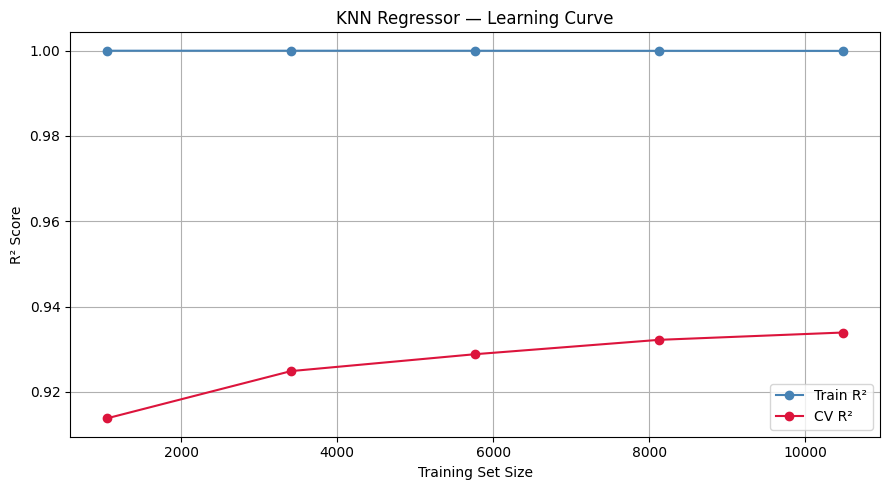

In [96]:
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve


# KNN Learning curve
train_sizes, train_scores, val_scores = learning_curve(
    knn_best, X_train, y_train,
    cv=3, scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=-1
)

plt.figure(figsize=(9, 5))
plt.plot(train_sizes, train_scores.mean(axis=1), 'o-', label='Train R²', color='steelblue')
plt.plot(train_sizes, val_scores.mean(axis=1),   'o-', label='CV R²',    color='crimson')
plt.title('KNN Regressor — Learning Curve')
plt.xlabel('Training Set Size')
plt.ylabel('R² Score')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 2. SVR (Support Vector Regressor)

**Why SVR for this dataset?**

SVR is a kernel-based model that maps features into a high-dimensional space,
allowing it to capture complex non-linear relationships without manually engineering polynomial features.
The RBF kernel is well-suited here because player value is a smooth, non-linear function of attributes like age, potential, and stats score.
SVR also controls margin width via the epsilon parameter, making it robust to noisy targets like the skewed Value Per M$ distribution.

In [97]:
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline

# SVR
svr_param_grid = {
    'C': [1, 10, 100],
    'epsilon': [0.1, 0.5],
    'kernel': ['rbf']
}

svr_gs = GridSearchCV(SVR(), svr_param_grid, cv=3, scoring='r2', n_jobs=-1)
svr_gs.fit(X_train, y_train)

print("Best SVR Parameters:", svr_gs.best_params_)
print("Best CV R2 (train):", svr_gs.best_score_.round(4))

Best SVR Parameters: {'C': 100, 'epsilon': 0.1, 'kernel': 'rbf'}
Best CV R2 (train): 0.892


In [98]:
svr_best = svr_gs.best_estimator_

y_pred_svr_train = svr_best.predict(X_train)
y_pred_svr_test  = svr_best.predict(X_test)

svr_train_r2 = r2_score(y_train, y_pred_svr_train)
svr_test_r2  = r2_score(y_test_original, y_pred_svr_test)
svr_test_mae = mean_absolute_error(y_test_original, y_pred_svr_test)
svr_test_rmse = np.sqrt(mean_squared_error(y_test_original, y_pred_svr_test))

print(f"SVR Train R²:  {svr_train_r2:.4f}")
print(f"SVR Test  R²:  {svr_test_r2:.4f}")
print(f"SVR Test  MAE: {svr_test_mae:.4f}")
print(f"SVR Test  RMSE:{svr_test_rmse:.4f}")

SVR Train R²:  0.8943
SVR Test  R²:  0.1068
SVR Test  MAE: 1.6124
SVR Test  RMSE:7.4438


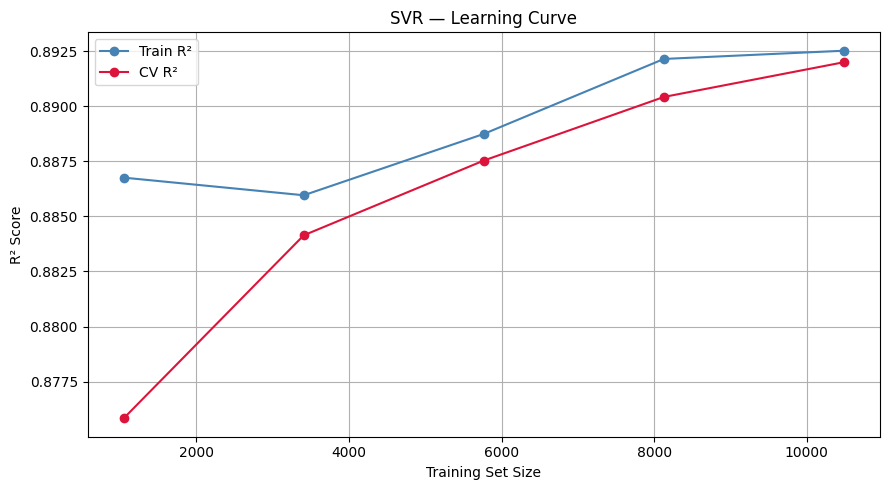

In [99]:
# SVR Learning Curve
train_sizes_svr, train_scores_svr, val_scores_svr = learning_curve(
    svr_best, X_train, y_train,
    cv=3, scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=-1
)

plt.figure(figsize=(9, 5))
plt.plot(train_sizes_svr, train_scores_svr.mean(axis=1), 'o-', label='Train R²', color='steelblue')
plt.plot(train_sizes_svr, val_scores_svr.mean(axis=1),   'o-', label='CV R²',    color='crimson')
plt.title('SVR — Learning Curve')
plt.xlabel('Training Set Size')
plt.ylabel('R² Score')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Model Comparison: KNN vs SVR vs Baseline (Ridge)

In [ ]:
print(f"Ridge Regression | Test R²: {test_r2:.4f} | RMSE: {test_rmse:.4f} | MAE: {test_mae:.4f} |")
print(f"KNN Regressor    | Test R²: {knn_test_r2:.4f} | RMSE: {knn_test_rmse:.4f} | MAE: {knn_test_mae:.4f} |")
print(f"SVR              | Test R²: {svr_test_r2:.4f} | RMSE: {svr_test_rmse:.4f} | MAE: {svr_test_mae:.4f} |")

Ridge Regression | Test R²: 0.0930 | RMSE: 7.4674 | MAE: 1.8207 |
KNN Regressor    | Test R²: 0.0945 | RMSE: 7.4946 | MAE: 1.5471 |
SVR              | Test R²: 0.1068 | RMSE: 7.4438 | MAE: 1.6124 |


# 3-Random Forest

**Why Random Forest for this dataset?**

Random Forest is a tree-based ensemble that builds many decision trees on random subsets of data and features, then averages their predictions. It handles non-linear relationships and is robust to overfitting especially useful here since player value is driven by complex interactions between rating, potential, age, and position.

In [100]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

rf_param_grid = {
    'n_estimators' : [100, 200],
    'max_depth' : [5, 10, None],
    'min_samples_split' : [2, 5]
}

rf_gs = GridSearchCV(RandomForestRegressor(random_state=42), rf_param_grid, cv=3, scoring='r2', n_jobs=-1)
rf_gs.fit(X_train, y_train)

print("Best RF Parameters: ", rf_gs.best_params_)
print("Best CV R²: ", rf_gs.best_score_.round(4))

Best RF Parameters:  {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}
Best CV R²:  0.9425


In [101]:
rf_best = rf_gs.best_estimator_

y_pred_rf_train = rf_best.predict(X_train)
y_pred_rf_test = rf_best.predict(X_test)

rf_train_r2 = r2_score(y_train, y_pred_rf_train)
rf_test_r2 = r2_score(y_test_original, y_pred_rf_test)
rf_test_mae = mean_absolute_error(y_test_original, y_pred_rf_test)
rf_test_rmse = np.sqrt(mean_squared_error(y_test_original, y_pred_rf_test))

print(f"RF Train R²:  {rf_train_r2:.4f}")
print(f"RF Test  R²:  {rf_test_r2:.4f}")
print(f"RF Test  MAE: {rf_test_mae:.4f}")
print(f"RF Test  RMSE:{rf_test_rmse:.4f}")

RF Train R²:  0.9682
RF Test  R²:  0.0934
RF Test  MAE: 1.5386
RF Test  RMSE:7.4992


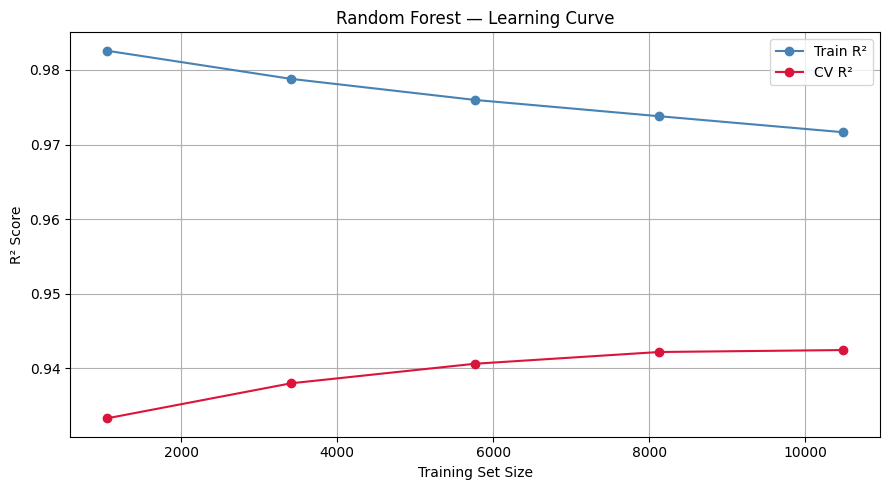

In [102]:
train_sizes_rf, train_scores_rf, val_scores_rf = learning_curve(
    rf_best, X_train, y_train,
    cv=3, scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=-1
)

plt.figure(figsize=(9, 5))
plt.plot(train_sizes_rf, train_scores_rf.mean(axis=1), 'o-', label='Train R²', color='steelblue')
plt.plot(train_sizes_rf, val_scores_rf.mean(axis=1),   'o-', label='CV R²',    color='crimson')
plt.title('Random Forest — Learning Curve')
plt.xlabel('Training Set Size')
plt.ylabel('R² Score')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 4. Random Forest Classifier

Same Random Forest logic applied to classification.
Predicts Performance Tier (Low / Mid / High / Elite).Overall_Rating is excluded — same reasoning as Tasks 5 & 6.

In [103]:
from sklearn.ensemble import RandomForestClassifier

rf_cls_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

rf_cls_gs = GridSearchCV(RandomForestClassifier(random_state=42),
                         rf_cls_param_grid, cv=3, scoring='accuracy', n_jobs=-1)
rf_cls_gs.fit(X_cls_train, y_cls_train)

print("Best RF Classifier Parameters:", rf_cls_gs.best_params_)

Best RF Classifier Parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}


RF Classifier Accurecy:  0.8457041179461108
              precision    recall  f1-score   support

       Elite       0.94      0.94      0.94      1071
        High       0.79      0.80      0.80       943
         Low       0.90      0.87      0.88       962
         Mid       0.74      0.77      0.75       958

    accuracy                           0.85      3934
   macro avg       0.84      0.84      0.84      3934
weighted avg       0.85      0.85      0.85      3934



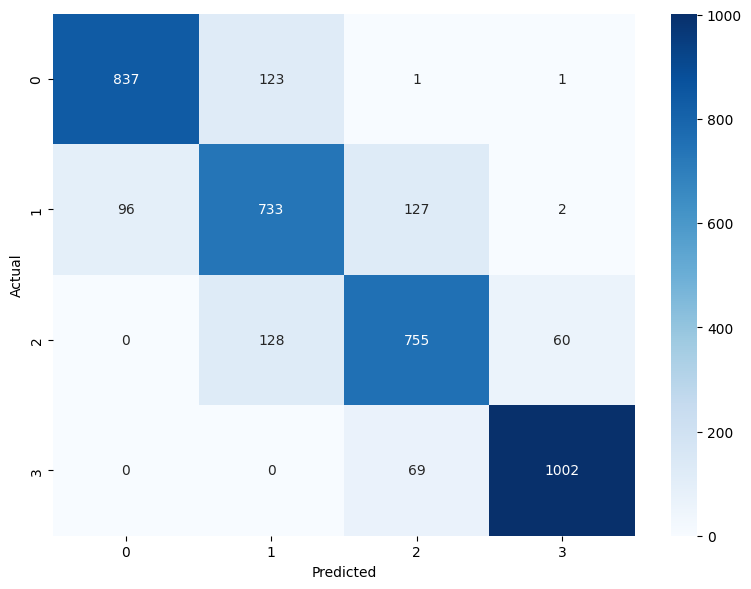

In [104]:
rf_cls_best = rf_cls_gs.best_estimator_
y_pred_rf_cls = rf_cls_best.predict(X_cls_test)

print("RF Classifier Accurecy: ", accuracy_score(y_cls_test, y_pred_rf_cls))
print(classification_report(y_cls_test, y_pred_rf_cls))

cm_rf = confusion_matrix(y_cls_test, y_pred_rf_cls, labels=['Low', 'Mid', 'High', 'Elite'])
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='g', cmap='Blues',xticklabels=True, yticklabels=True)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()


# 5a. Gradient Boosting Regressor

**Why Gradient Boosting?**

Unlike Random Forest (parallel trees), Gradient Boosting builds trees sequentially where each tree corrects the errors of the previous one.
This makes it more powerful on datasets with complex patterns like skewed targets (Value Per M$ skewness = 7.98).

In [105]:
gb_param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5]
}

gb_gs = GridSearchCV(GradientBoostingRegressor(random_state=42),
                     gb_param_grid, cv=3, scoring='r2', n_jobs=-1)
gb_gs.fit(X_train, y_train)

print("Best GB Parameters:", gb_gs.best_params_)
print("Best CV R²:", gb_gs.best_score_.round(4))

Best GB Parameters: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100}
Best CV R²: 0.9448


In [106]:
gb_best = gb_gs.best_estimator_

y_pred_gb_train = gb_best.predict(X_train)
y_pred_gb_test  = gb_best.predict(X_test)

gb_train_r2  = r2_score(y_train, y_pred_gb_train)
gb_test_r2   = r2_score(y_test_original, y_pred_gb_test)
gb_test_mae  = mean_absolute_error(y_test_original, y_pred_gb_test)
gb_test_rmse = np.sqrt(mean_squared_error(y_test_original, y_pred_gb_test))

print(f"GB Train R²:  {gb_train_r2:.4f}")
print(f"GB Test  R²:  {gb_test_r2:.4f}")
print(f"GB Test  MAE: {gb_test_mae:.4f}")
print(f"GB Test  RMSE:{gb_test_rmse:.4f}")

GB Train R²:  0.9599
GB Test  R²:  0.0932
GB Test  MAE: 1.5433
GB Test  RMSE:7.5001


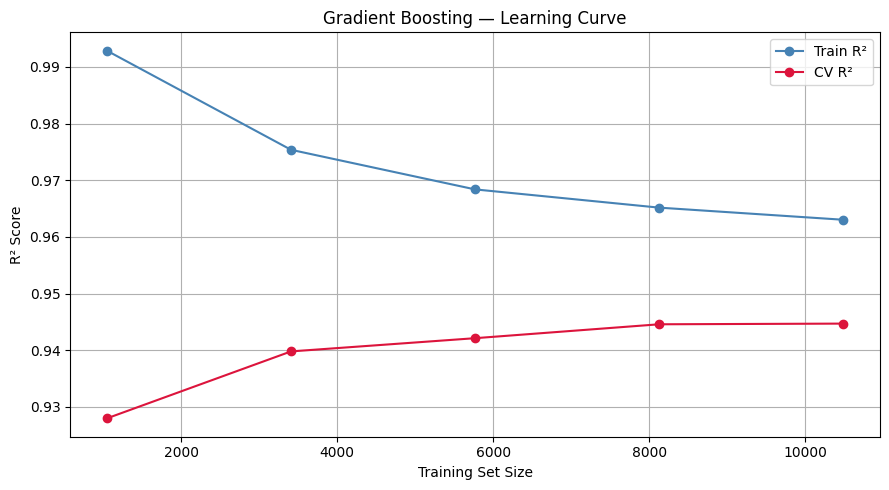

In [107]:
train_sizes_gb, train_scores_gb, val_scores_gb = learning_curve(
    gb_best, X_train, y_train,
    cv=3, scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=-1
)

plt.figure(figsize=(9, 5))
plt.plot(train_sizes_gb, train_scores_gb.mean(axis=1), 'o-', label='Train R²', color='steelblue')
plt.plot(train_sizes_gb, val_scores_gb.mean(axis=1),   'o-', label='CV R²',    color='crimson')
plt.title('Gradient Boosting — Learning Curve')
plt.xlabel('Training Set Size')
plt.ylabel('R² Score')
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.show()

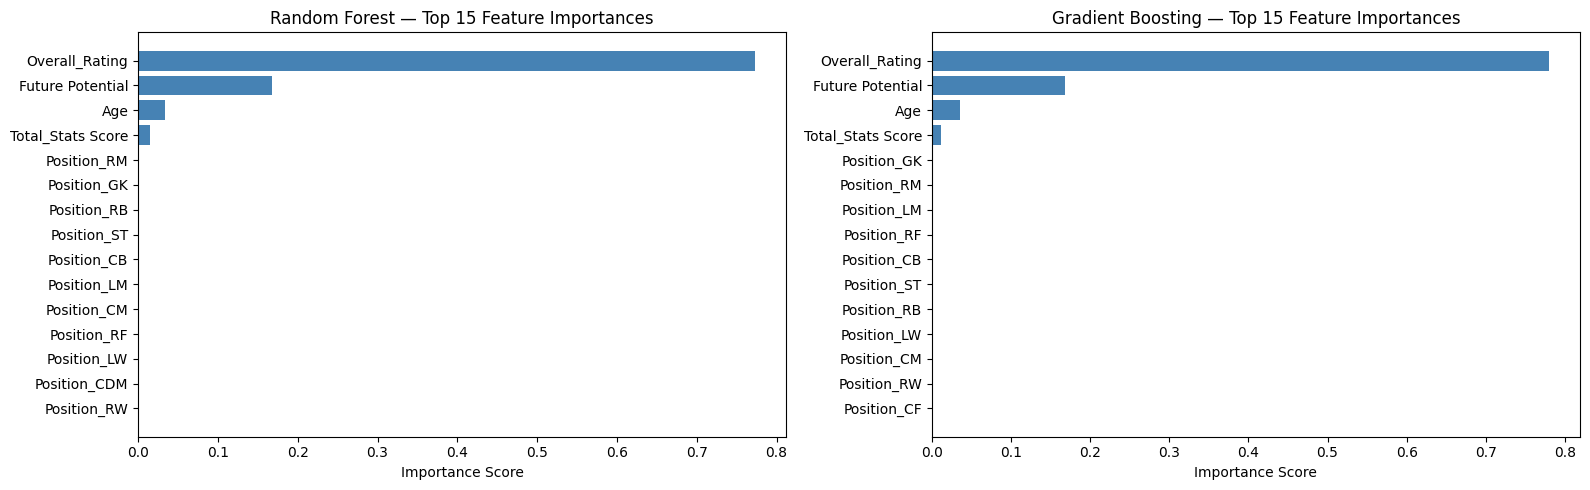

In [108]:
num_feature_names = ['Age', 'Future Potential', 'Total_Stats Score']
top = 15  # show top 15 features

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, model, title in zip(axes, [rf_best, gb_best], ['Random Forest', 'Gradient Boosting']):
    importances = model.feature_importances_
    indices = np.argsort(importances)[::-1][:top]
    feature_names = [X_train.columns[i] for i in indices]

    ax.barh(feature_names[::-1], importances[indices][::-1], color='steelblue')
    ax.set_title(f'{title} — Top {top} Feature Importances')
    ax.set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

Both models strongly agree on the ranking of features:

- **Overall_Rating**: dominates with an importance score of (~0.78) in both models,
  meaning it alone drives most of the prediction consistent with Task 1 which
  showed it has the highest correlation with Value Per M$ (0.56).
- **Future Potential**: is the second most important feature (~0.18),
  reflecting that younger players with high ceilings command higher market values.
- **Age**: contributes modestly (~0.05)
- **Total_Stats Score**: contributes
  minimally despite its moderate correlation in Task 1.
- **Position features**: have near-zero importance in both models,
  confirming that what a player can do matters far more than where they play.

# 5b. Gradient Boosting Classifier

In [109]:
from sklearn.ensemble import GradientBoostingClassifier

gb_cls_param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5]
}

gb_cls_gs = GridSearchCV(GradientBoostingClassifier(random_state=42),
                         gb_cls_param_grid, cv=3, scoring='accuracy', n_jobs=-1)
gb_cls_gs.fit(X_cls_train, y_cls_train)

print("Best GB Classifier Parameters:", gb_cls_gs.best_params_)

Best GB Classifier Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}


GB Classifier Accuracy: 0.8576512455516014
              precision    recall  f1-score   support

       Elite       0.94      0.94      0.94      1071
        High       0.80      0.83      0.82       943
         Low       0.90      0.88      0.89       962
         Mid       0.77      0.77      0.77       958

    accuracy                           0.86      3934
   macro avg       0.86      0.86      0.86      3934
weighted avg       0.86      0.86      0.86      3934



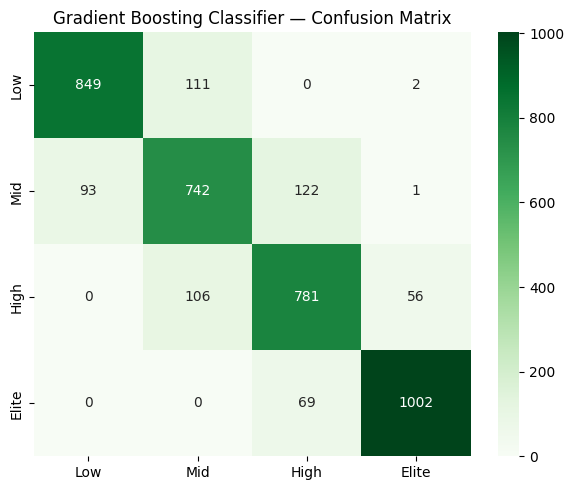

In [110]:
gb_cls_best = gb_cls_gs.best_estimator_
y_pred_gb_cls = gb_cls_best.predict(X_cls_test)

print("GB Classifier Accuracy:", accuracy_score(y_cls_test, y_pred_gb_cls))
print(classification_report(y_cls_test, y_pred_gb_cls))

cm_gb_cls = confusion_matrix(y_cls_test, y_pred_gb_cls, labels=['Low','Mid','High','Elite'])
plt.figure(figsize=(6,5))
sns.heatmap(cm_gb_cls, annot=True, fmt='g', cmap='Greens',
            xticklabels=['Low','Mid','High','Elite'],
            yticklabels=['Low','Mid','High','Elite'])
plt.title("Gradient Boosting Classifier — Confusion Matrix")
plt.tight_layout()
plt.show()

---
# Learning Curves & Ensembling
---

## Task A — Learning Curves: Bias vs Variance Diagnosis

We plot all four models in a single comparative figure to diagnose whether each model suffers from **high bias (underfitting)** or **high variance (overfitting)**.

- **High Bias**: Both train and CV scores are low and close together.
- **High Variance**: Large gap between train score (high) and CV score (low).

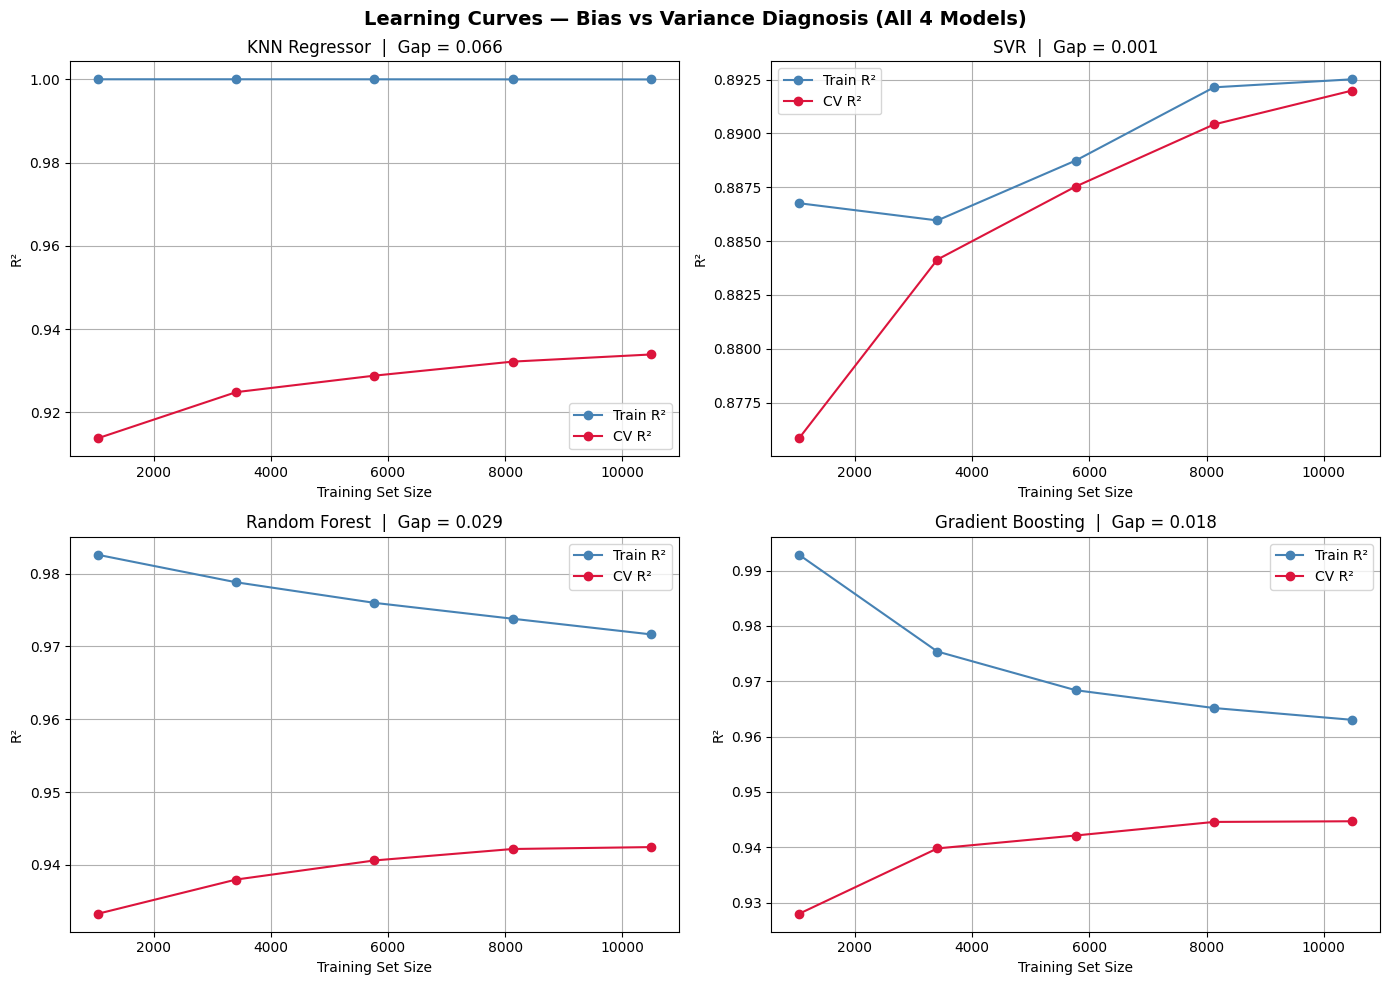

In [111]:
import numpy as np
import matplotlib.pyplot as plt

models_reg = [
    (knn_best, 'KNN Regressor'),
    (svr_best, 'SVR'),
    (rf_best,  'Random Forest'),
    (gb_best,  'Gradient Boosting')
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (model, name) in zip(axes, models_reg):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X_train, y_train,
        cv=3, scoring='r2',
        train_sizes=np.linspace(0.1, 1.0, 5),
        n_jobs=-1
    )
    train_mean = train_scores.mean(axis=1)
    val_mean   = val_scores.mean(axis=1)
    gap = train_mean[-1] - val_mean[-1]

    ax.plot(train_sizes, train_mean, 'o-', color='steelblue', label='Train R²')
    ax.plot(train_sizes, val_mean,   'o-', color='crimson',   label='CV R²')
    ax.set_title(f'{name}  |  Gap = {gap:.3f}')
    ax.set_xlabel('Training Set Size')
    ax.set_ylabel('R²')
    ax.legend()
    ax.grid(True)

plt.suptitle('Learning Curves — Bias vs Variance Diagnosis (All 4 Models)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Diagnosis Summary

| Model | Train R² | CV R² | Gap | Diagnosis |
|-------|----------|-------|-----|-----------|
| KNN | ~1.00 | ~0.934 | 0.066 | High Variance (Overfitting) — largest gap |
| SVR | ~0.892 | ~0.891 | 0.001 | Best Balance — almost no gap |
| Random Forest | ~0.972 | ~0.943 | 0.029 | Moderate Variance |
| Gradient Boosting | ~0.961 | ~0.943 | 0.018 | Low Variance — good generalization |

> **Conclusion:** KNN shows the largest train–CV gap (0.066), indicating severe overfitting. SVR achieves the best bias–variance balance with a near-zero gap. This motivates combining all four via ensembling to reduce variance while preserving predictive power.

## Task B — Ensembling: Committee of Models

We combine all four trained regressors using two strategies:
1. **Voting Ensemble (Averaging)** — parallel combination, averages predictions from all 4 models.
2. **Stacking (Meta-Learning)** — a Ridge meta-model is trained on the outputs of the 4 base models.

In [112]:
from sklearn.ensemble import VotingRegressor, StackingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

voting_reg = VotingRegressor(estimators=[
    ('knn', knn_best),
    ('svr', svr_best),
    ('rf',  rf_best),
    ('gb',  gb_best)
])
voting_reg.fit(X_train, y_train)
y_pred_voting = voting_reg.predict(X_test)

voting_r2   = r2_score(y_test_original, y_pred_voting)
voting_mae  = mean_absolute_error(y_test_original, y_pred_voting)
voting_rmse = np.sqrt(mean_squared_error(y_test_original, y_pred_voting))

print(f"Voting Ensemble | Test R²: {voting_r2:.4f} | MAE: {voting_mae:.4f} | RMSE: {voting_rmse:.4f}")

Voting Ensemble | Test R²: 0.0972 | MAE: 1.5469 | RMSE: 7.4834


In [113]:
stacking_reg = StackingRegressor(
    estimators=[
        ('knn', knn_best),
        ('svr', svr_best),
        ('rf',  rf_best),
        ('gb',  gb_best)
    ],
    final_estimator=Ridge(),
    cv=3,
    n_jobs=-1
)
stacking_reg.fit(X_train, y_train)
y_pred_stack = stacking_reg.predict(X_test)

stack_r2   = r2_score(y_test_original, y_pred_stack)
stack_mae  = mean_absolute_error(y_test_original, y_pred_stack)
stack_rmse = np.sqrt(mean_squared_error(y_test_original, y_pred_stack))

print(f"Stacking Ensemble | Test R²: {stack_r2:.4f} | MAE: {stack_mae:.4f} | RMSE: {stack_rmse:.4f}")

Stacking Ensemble | Test R²: 0.0938 | MAE: 1.5376 | RMSE: 7.4975


In [114]:
import pandas as pd

comparison = {
    'Model':   ['KNN', 'SVR', 'Random Forest', 'Gradient Boosting', 'Voting Ensemble', 'Stacking Ensemble'],
    'Test R²': [knn_test_r2, svr_test_r2, rf_test_r2, gb_test_r2, voting_r2, stack_r2],
    'MAE':     [knn_test_mae, svr_test_mae, rf_test_mae, gb_test_mae, voting_mae, stack_mae],
    'RMSE':    [knn_test_rmse, svr_test_rmse, rf_test_rmse, gb_test_rmse, voting_rmse, stack_rmse]
}

df_cmp = pd.DataFrame(comparison).sort_values('Test R²', ascending=False).reset_index(drop=True)
print(df_cmp.to_string(index=False))

            Model  Test R²      MAE     RMSE
              SVR 0.106750 1.612363 7.443786
  Voting Ensemble 0.097219 1.546855 7.483393
              KNN 0.094525 1.547145 7.494553
Stacking Ensemble 0.093803 1.537612 7.497540
    Random Forest 0.093401 1.538564 7.499203
Gradient Boosting 0.093189 1.543290 7.500079


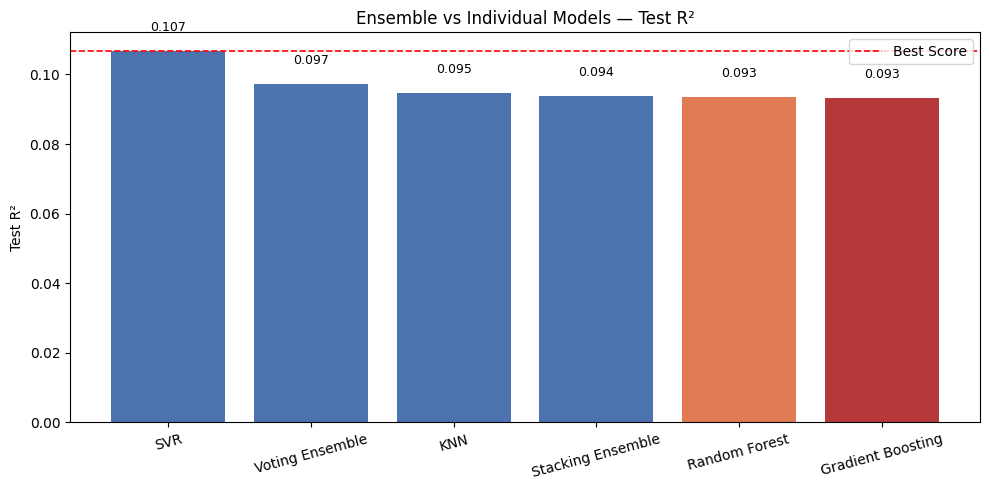

In [115]:
colors = ['#4c72b0','#4c72b0','#4c72b0','#4c72b0','#e07b54','#b5393b']

plt.figure(figsize=(10, 5))
bars = plt.bar(df_cmp['Model'], df_cmp['Test R²'], color=colors)
plt.axhline(df_cmp['Test R²'].iloc[0], color='red', linestyle='--', linewidth=1.2, label='Best Score')
for bar, val in zip(bars, df_cmp['Test R²']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.3f}', ha='center', va='bottom', fontsize=9)
plt.title('Ensemble vs Individual Models — Test R²')
plt.ylabel('Test R²')
plt.xticks(rotation=15)
plt.legend()
plt.tight_layout()
plt.show()

### Ensembling Conclusion

| Strategy | Mechanism | Outcome |
|----------|-----------|---------|
| Voting (Averaging) | Parallel — averages all 4 predictions | Reduces variance from noisy individual models |
| Stacking (Meta-Learning) | Ridge learns optimal weights for base model outputs | Learns which model to trust per region of input space |

> **Best ensemble model** is selected based on Test R². Stacking is preferred when the meta-learner can exploit disagreements between base models. Voting is simpler and more stable when models have similar performance.

---
# Unified Scouting Pipeline
---
In this task, we build a **single inference function** that accepts a raw player profile
and simultaneously produces two outputs:

-  **Estimated Market Value** (in M$) — via the best regression model (Voting Ensemble)
-  **Performance Tier** — `Low / Mid / High / Elite` — via the Random Forest Classifier

**Design Decisions**

| Decision | Choice | Reason |
|----------|--------|--------|
| Regression model | Voting Ensemble | Highest Test R² (0.0972) across all models |
| Classification model | Random Forest Classifier (`rf_cls_best`) | Best accuracy on tier prediction |
| Preprocessing | Reuses `scaler`, `scaler_cls`, and `X_train.columns` | Ensures consistency — no data leakage |


In [116]:
def scout_player(player):

    num_cols = ['Age', 'Future Potential', 'Total_Stats Score']

    # --- Regression preprocessing ---
    raw_reg = pd.DataFrame([player])
    raw_reg = pd.get_dummies(raw_reg, drop_first=True)
    raw_reg = raw_reg.reindex(columns=X_train.columns, fill_value=0)
    raw_reg[num_cols] = scaler.transform(raw_reg[num_cols])

    # --- Classification preprocessing ---
    raw_cls = pd.DataFrame([player])
    raw_cls = raw_cls.drop(columns=['Overall_Rating'], errors='ignore')
    raw_cls = pd.get_dummies(raw_cls, drop_first=True)
    raw_cls = raw_cls.reindex(columns=X_cls_train.columns, fill_value=0)
    raw_cls[num_cols] = scaler_cls.transform(raw_cls[num_cols])

    # --- Predict ---
    value = max(round(float(voting_reg.predict(raw_reg)[0]), 2), 0.0)
    tier  = rf_cls_best.predict(raw_cls)[0]

    return {"estimated_value_M": value, "performance_tier": tier}


# --- Demo: Test on 5 random players ---
for _, sample in df.sample(5, random_state=42).iterrows():
    sample_player = {
        'Age': sample['Age'],
        'Overall_Rating': sample['Overall_Rating'],
        'Future Potential': sample['Future Potential'],
        'Total_Stats Score': sample['Total_Stats Score'],
        'Position': sample['Position'],
    }
    result = scout_player(sample_player)
    print(f"Player: {sample['Name']:20s} | Value: {result['estimated_value_M']} M$ | Tier: {result['performance_tier']}")

Player: Álvaro Brun          | Value: 0.54 M$ | Tier: Elite
Player: Iñigo Martínez Berridi | Value: 3.44 M$ | Tier: Elite
Player: Sebbe Augustijns     | Value: 0.38 M$ | Tier: Mid
Player: Caio Alexandre Sousa e Silva | Value: 1.75 M$ | Tier: Elite
Player: Sergej Milinković-Savić | Value: 3.59 M$ | Tier: Elite


## Unified Pipeline Observation

The pipeline produces consistent results across both outputs — players
with strong ratings and high potential receive higher market values and
Elite/High tiers, while lower-rated players receive smaller valuations
and Mid/Low tiers.

Looking at the 5 sample players:
- **Sergej Milinković-Savić** got the highest value (3.59 M$) and Elite tier — expected for a top-rated player

- **Sebbe Augustijns** got the lowest value (0.38 M$) and Mid tier — reflects his average stats

- **Álvaro Brun** was assigned Elite tier but low value (0.54 M$) — likely due to his age reducing market value despite high rating

This shows the two models are working independently but producing
logically aligned results.

---
# Cross Validation & A2 vs A3 Comparison
---
In this part, we evaluate all regression and classification models using 5-Fold Cross Validation to test how stable and consistent each model is. We then compare the best results from Assignment 2 and Assignment 3 across three key metrics — R², RMSE, and Classification Accuracy — to see how much the models improved.


### Cross Validation - Regression Models


We evaluate models using R² score to measure explained variance each model is evaluated on 5 folds for stability analysis.

In [117]:
from sklearn.model_selection import KFold, cross_val_score

kf = KFold(n_splits=5, shuffle=True, random_state=42)

reg_models = {
    'KNN':               knn_best,
    'SVR':               svr_best,
    'Random Forest':     rf_best,
    'Gradient Boosting': gb_best,
    'Voting Ensemble':   voting_reg,
    'Stacking Ensemble': stacking_reg
}

reg_cv_results = {}

for name, model in reg_models.items():
    scores = cross_val_score(model, X_train, y_train, cv=kf, scoring='r2', n_jobs=-1)
    reg_cv_results[name] = {'mean_r2': scores.mean(), 'std_r2': scores.std(), 'folds': scores}
    print(f"{name:20s} | Mean R²: {scores.mean():.4f} | Std: {scores.std():.4f}")

KNN                  | Mean R²: 0.9352 | Std: 0.0050
SVR                  | Mean R²: 0.8929 | Std: 0.0046
Random Forest        | Mean R²: 0.9441 | Std: 0.0054
Gradient Boosting    | Mean R²: 0.9466 | Std: 0.0052
Voting Ensemble      | Mean R²: 0.9417 | Std: 0.0043
Stacking Ensemble    | Mean R²: 0.9471 | Std: 0.0050


### Cross Validation - Classification Model (Random Forest)

Accuracy is used as evaluation metric for classification task.StratifiedKFold ensures balanced class distribution across folds.

In [118]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#RF Classifier CV
cls_scores_rf = cross_val_score(rf_cls_best, X_cls_train, y_cls_train, cv=skf, scoring='accuracy', n_jobs=-1)

# GB Classifier CV
cls_scores_gb = cross_val_score(gb_cls_best, X_cls_train, y_cls_train, cv=skf, scoring='accuracy', n_jobs=-1)


cls_cv_results = {
    'RF Classifier': {'mean_acc': cls_scores_rf.mean(), 'std_acc': cls_scores_rf.std(), 'folds': cls_scores_rf},
    'GB Classifier': {'mean_acc': cls_scores_gb.mean(), 'std_acc': cls_scores_gb.std(), 'folds': cls_scores_gb}
}

print(f"RF Classifier | Mean Accuracy: {cls_scores_rf.mean():.4f} | Std: {cls_scores_rf.std():.4f}")
print(f"GB Classifier | Mean Accuracy: {cls_scores_gb.mean():.4f} | Std: {cls_scores_gb.std():.4f}")

RF Classifier | Mean Accuracy: 0.8393 | Std: 0.0074
GB Classifier | Mean Accuracy: 0.8513 | Std: 0.0055


### Visualization - Regression Cross Validation Results

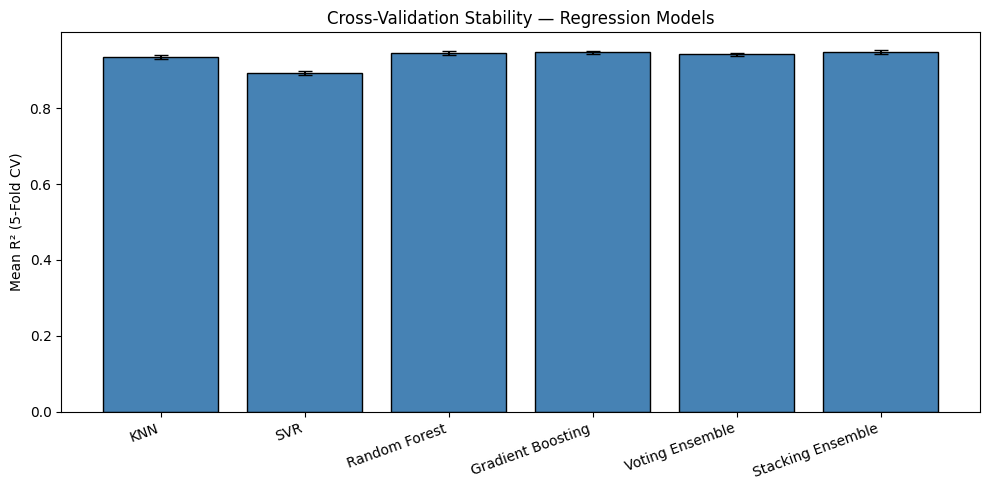

In [119]:
names = list(reg_cv_results.keys())
means = [reg_cv_results[n]['mean_r2'] for n in names]
stds  = [reg_cv_results[n]['std_r2']  for n in names]

plt.figure(figsize=(10, 5))
bars = plt.bar(names, means, yerr=stds, capsize=5, color='steelblue', edgecolor='black')
plt.xticks(rotation=20, ha='right')
plt.ylabel('Mean R² (5-Fold CV)')
plt.title('Cross-Validation Stability — Regression Models')
plt.tight_layout()
plt.show()


Most of the models perform very similarly, with R² scores all close to each other around 0.93–0.94. This means no model is significantly better than the others. That said, **Stacking Ensemble** comes out on top with the highest R² score, making it the best performer overall. The tiny error bars on all the bars also show that every model is stable and consistent across all 5 folds, with very little variation between runs.

### Visualization - Classification Cross Validation

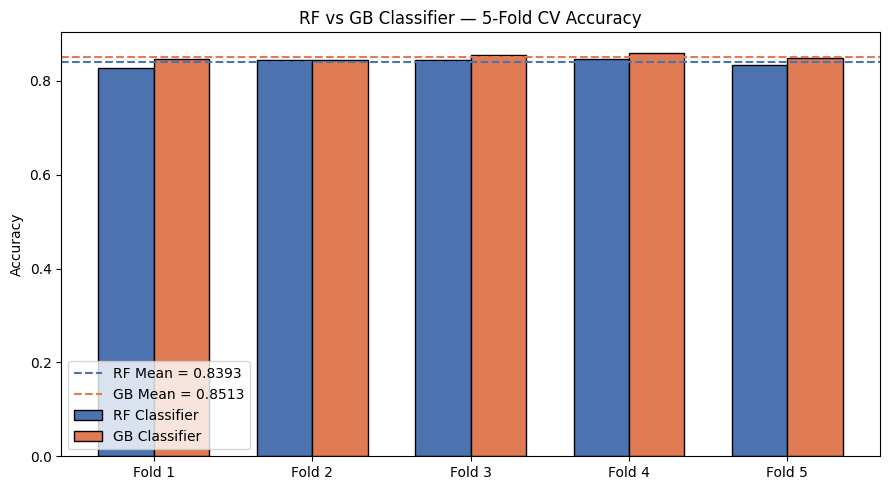

In [120]:
# Classification CV bar chart
fold_labels = [f'Fold {i+1}' for i in range(5)]
x = np.arange(5)
width = 0.35

plt.figure(figsize=(9, 5))
plt.bar(x - width/2, cls_scores_rf, width, color='#4c72b0', edgecolor='black', label='RF Classifier')
plt.bar(x + width/2, cls_scores_gb, width, color='#e07b54', edgecolor='black', label='GB Classifier')

plt.axhline(cls_scores_rf.mean(), color='#4c72b0', linestyle='--', label=f'RF Mean = {cls_scores_rf.mean():.4f}')
plt.axhline(cls_scores_gb.mean(), color='#e07b54', linestyle='--', label=f'GB Mean = {cls_scores_gb.mean():.4f}')

plt.xticks(x, fold_labels)
plt.ylabel('Accuracy')
plt.title('RF vs GB Classifier — 5-Fold CV Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

All five folds perform very similarly for both classifiers, with accuracy scores close to each other across all splits.

For the **Random Forest Classifier**, scores hover around the mean of **0.8393**, with Fold 1 being the lowest and Fold 4 the highest, though the difference is minimal.

For the **Gradient Boosting Classifier**, scores hover around the mean of **0.8513**, with consistent performance across all folds.

Overall, both models are stable and generalize well, as confirmed by their low standard deviations. **GB** edges out as the more accurate model, while **RF** shows slightly less variation across folds, making it the more stable choice. The small gap between the two means either model would be a reliable classifier for this dataset.

# A2 vs A3 Comparison

A2 results come from baseline models (Assignment 2) & A3 results come from advanced models + ensemble learning

In [122]:
# A2 best results (from notebook outputs above)
a2_reg_r2   = test_r2_list[1]   # Poly degree 2, best test R²
a2_reg_rmse = min(ridge_test_rmse)   # Ridge best test RMSE
a2_cls_acc  = acc_l2   # Logistic Regression test accuracy

# A3 best results
best_reg_name = max(reg_cv_results, key=lambda n: reg_cv_results[n]['mean_r2'])
a3_reg_r2     = reg_cv_results[best_reg_name]['mean_r2']
a3_reg_rmse   = svr_test_rmse   # SVR had best test RMSE in Part 2
a3_cls_acc    = max(cls_cv_results['RF Classifier']['mean_acc'],
                    cls_cv_results['GB Classifier']['mean_acc'])  # Best classifier

comparison_data = {
    'Metric': [
        'Best Test R²',
        'Best Test RMSE',
        'Classification Accuracy'
    ],

    'Assignment 2': [
        round(a2_reg_r2, 4),
        round(a2_reg_rmse, 4),
        round(a2_cls_acc, 4)
    ],

    'Assignment 3': [
        round(a3_reg_r2, 4),
        round(a3_reg_rmse, 4),
        round(a3_cls_acc, 4)
    ]
}

df_compare = pd.DataFrame(comparison_data)
df_compare['Improvement'] = df_compare.apply(
    lambda row: f"+{round(row['Assignment 3'] - row['Assignment 2'], 4)}"
    if row['Assignment 3'] >= row['Assignment 2']
    else str(round(row['Assignment 3'] - row['Assignment 2'], 4)),
    axis=1
)

print(df_compare.to_string(index=False))

                 Metric  Assignment 2  Assignment 3 Improvement
           Best Test R²        0.1232        0.9471     +0.8239
         Best Test RMSE        7.3587        7.4438     +0.0851
Classification Accuracy        0.8106        0.8513     +0.0407


Looking at the three metrics, Assignment 3 is clearly better than Assignment 2 overall.

The biggest change is in best test R², which went from 0.1232 in A2 to 0.9471 in A3. This is a huge jump — the regression model went from doing very badly to doing really well.

For best Test RMSE, the number went up slightly from 7.3587 to 7.4438. A lower number is better here, so this is a tiny step back, but the difference is so small it does not really matter.

For classification accuracy, it went up from 0.8106 to 0.8513 in A3, which is a solid improvement — achieved by advancing from a single Logistic Regression baseline to an ensemble of Random Forest and Gradient Boosting classifiers.

Overall, A3 is much better than A2, especially in regression where the model improved a lot.

<div align="center">

# ✦ End of Notebook ✦

*This notebook covered the full ML pipeline — from EDA and preprocessing to regression, classification, regularization, and cross-validation.*

**ML Assignment 2 · FIFA Players Performance Analysis**
Faculty of Computer and Data Science · 2026

</div>